# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import (
    LogisticRegression, RidgeClassifier, SGDClassifier,
    LinearRegression, Ridge, Lasso, ElasticNet
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss,
    roc_curve, precision_recall_curve
)
from sklearn.dummy import DummyClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [4]:
df = pd.read_csv("./Dataset/dataset.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
print(f"Shape : {df.shape}")
print("\n")
print(f"Datyatypes:\n{df.dtypes}")
print("\n")
print(f"Null Values:\n{df.isnull().sum()}")
print("\n")
tc_blanks = (df['TotalCharges'].str.strip() == '').sum()
print(f"TotalCharges hidden blank entries: {tc_blanks}")

Shape : (7043, 21)


Datyatypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


Null Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            

In [21]:
print(f"Summary Statistics:\n{df.describe()}")
print("\n")
print("\n--- Categorical Columns (unique values) ---")
cat_cols = df.select_dtypes(include="object").columns.tolist()
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique): {df[col].unique()[:6]}")

Summary Statistics:
       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000



--- Categorical Columns (unique values) ---

customerID (7043 unique): <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC']
Length: 6, dtype: str

gender (2 unique): <StringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner (2 unique): <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents (2 unique): <StringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService (2 unique): <StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines (3 unique): <StringArra

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- **X (feature space):** All customer attributes excluding `customerID` and 
  `Churn` — tenure, contract type, monthly charges, internet/phone services, 
  payment method, and demographics. ~20 features after dropping the ID column.

- **y (target variable):** `Churn` — binary: 1 = customer left, 0 = stayed.

- **Probability distribution of y:** Bernoulli — each customer either churns 
  or doesn't. A single binary outcome per observation.

- **Natural loss function:** Binary cross-entropy (log loss). Minimising it 
  is equivalent to maximum likelihood estimation under the Bernoulli assumption.

- **Hypothesis class:** Linear models — the decision boundary is a hyperplane 
  in feature space. Logistic Regression maps the linear score through a sigmoid 
  to output a probability.

- **Assumption 1:** The log-odds of churn are linearly separable — a linear 
  combination of features is sufficient to distinguish churners from non-churners.

- **Assumption 2:** Observations are i.i.d. — each customer's churn decision 
  is independent of all others.

- **Assumption 3:** The training distribution represents future customers — 
  no significant distribution shift between data collection and deployment.

- **Sources of uncertainty:**
  - *Sampling noise*: 7,043 customers is a finite sample — estimates have variance.
  - *Label noise*: Churn may be mislabelled for customers who cancelled and re-subscribed.
  - *Missing data*: 11 blank `TotalCharges` entries — likely new customers, not random.
  - *Distribution shift*: Pricing or competitor landscape may have changed since collection.
  - *Model misspecification*: A linear boundary may miss non-linear interactions 
    (e.g., high charges only matter for short-tenure customers).

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [22]:
# your code here
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("TotalCharges nulls remaining:", df['TotalCharges'].isnull().sum())
print("\nChurn value counts:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.1%}")



TotalCharges dtype: float64
TotalCharges nulls remaining: 0

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 26.5%


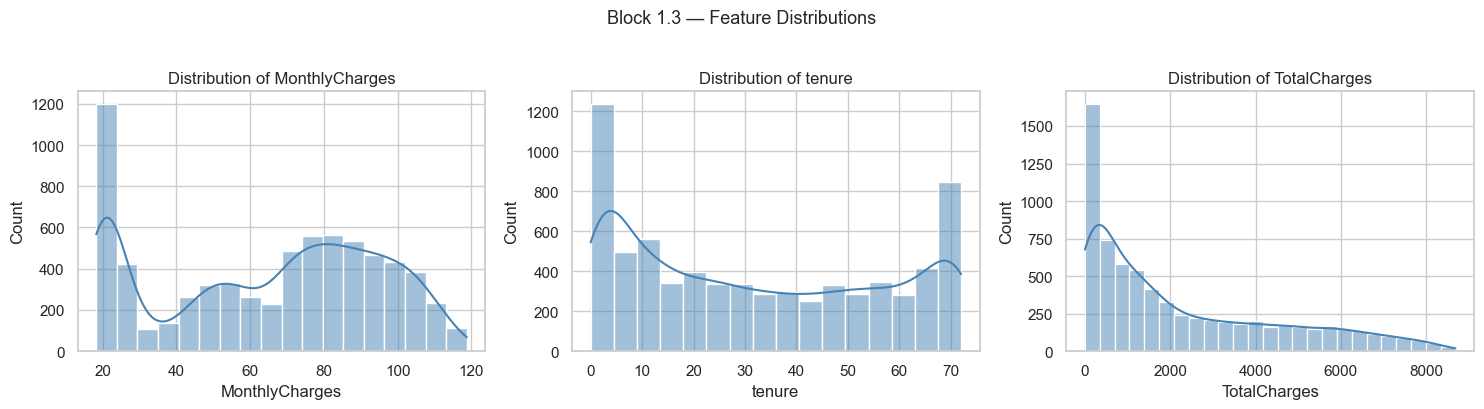

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ['MonthlyCharges', 'tenure', 'TotalCharges']):
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Block 1.3 — Feature Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

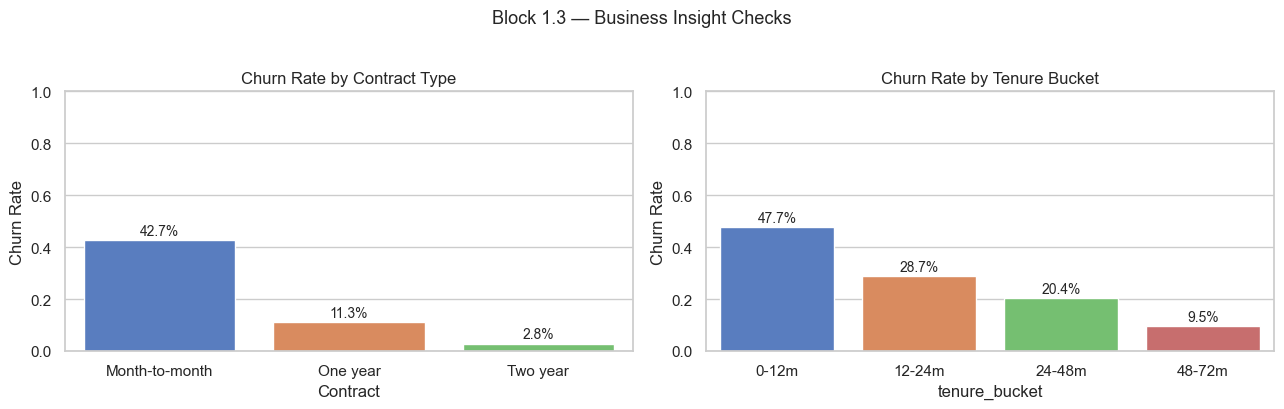

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


churn_by_contract = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
sns.barplot(x=churn_by_contract.index, y=churn_by_contract.values, ax=axes[0], palette='muted')
axes[0].set_title('Churn Rate by Contract Type')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 1)
for i, v in enumerate(churn_by_contract.values):
    axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)


df['tenure_bucket'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=['0-12m','12-24m','24-48m','48-72m'])
churn_by_tenure = df.groupby('tenure_bucket', observed=True)['Churn'].mean()
sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure.values, ax=axes[1], palette='muted')
axes[1].set_title('Churn Rate by Tenure Bucket')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 1)
for i, v in enumerate(churn_by_tenure.values):
    axes[1].text(i, v + 0.02, f'{v:.1%}', ha='center', fontsize=10)

plt.suptitle('Block 1.3 — Business Insight Checks', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score


X_temp = df.drop(columns=['Churn', 'customerID', 'tenure_bucket'])
y_temp = df['Churn']

X_tr_temp, X_val_temp, y_tr_temp, y_val_temp = train_test_split(
    X_temp, y_temp, test_size=0.3, stratify=y_temp, random_state=42
)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_tr_temp, y_tr_temp)
y_pred_dummy = dummy.predict(X_val_temp)

print("--- Naive Baseline Results ---")
print(f"Accuracy : {accuracy_score(y_val_temp, y_pred_dummy):.4f}")
print(f"Recall   : {recall_score(y_val_temp, y_pred_dummy):.4f}")
print(f"F1 Score : {f1_score(y_val_temp, y_pred_dummy):.4f}")
print()
print("This model catches ZERO churners.")
print("It is completely useless — yet reports high accuracy.")

--- Naive Baseline Results ---
Accuracy : 0.7345
Recall   : 0.0000
F1 Score : 0.0000

This model catches ZERO churners.
It is completely useless — yet reports high accuracy.


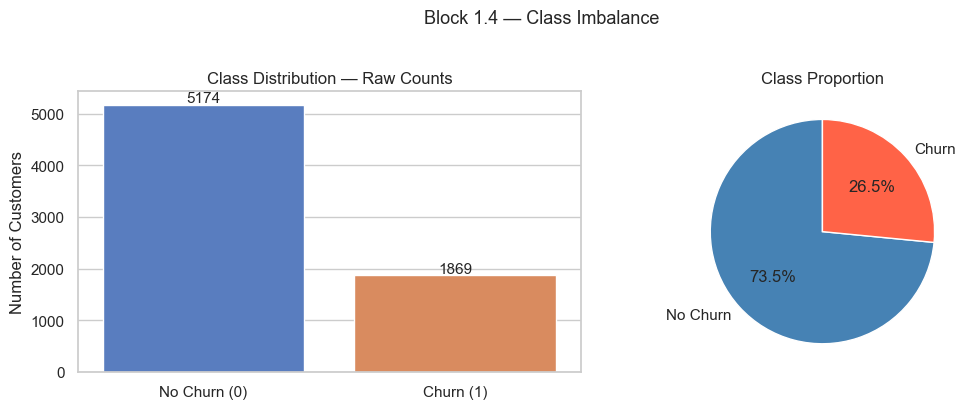


Majority class (No Churn): 73.5%
Minority class (Churn)   : 26.5%

Baseline accuracy any model must beat: 73.5%
But beating it on ACCURACY alone is not enough — beat it on RECALL and F1.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))


counts = df['Churn'].value_counts()
sns.barplot(x=['No Churn (0)', 'Churn (1)'], y=counts.values, ax=axes[0], palette='muted')
axes[0].set_title('Class Distribution — Raw Counts')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11)

props = df['Churn'].value_counts(normalize=True)
axes[1].pie(
    props.values,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90
)
axes[1].set_title('Class Proportion')

plt.suptitle('Block 1.4 — Class Imbalance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMajority class (No Churn): {props[0]:.1%}")
print(f"Minority class (Churn)   : {props[1]:.1%}")
print(f"\nBaseline accuracy any model must beat: {props[0]:.1%}")
print("But beating it on ACCURACY alone is not enough — beat it on RECALL and F1.")

---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

No — they should not be thrilled. The first question to ask is:

**"What is the recall for churners?"**

A model that always predicts No Churn achieves 73% accuracy but 0% recall —
it identifies zero customers at risk. The business cannot act on it at all.

Accuracy is misleading here because the classes are imbalanced (73/27 split).
The right metrics are:
- **Recall** — are we catching the churners?
- **F1 / PR-AUC** — are we balancing precision and recall honestly?

A model is only useful if it gives the retention team actionable, 
prioritised leads — not a list that ignores 27% of the problem entirely.

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [28]:
df_model= df.drop(columns=['customerID', 'tenure_bucket'])
df_model = pd.get_dummies(df_model, drop_first=True)

print(f"Shape after encoding: {df_model.shape}")
print(f"\nFeature columns ({df_model.shape[1] - 1} total):")
print([col for col in df_model.columns if col != 'Churn'])

Shape after encoding: (7043, 31)

Feature columns (30 total):
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [29]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

# Step 1: Split off 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)


# Step 2: Split the 30% temp evenly into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("--- Split Sizes ---")
print(f"Train : {X_train.shape[0]} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Val   : {X_val.shape[0]} rows ({X_val.shape[0]/len(X):.0%})")
print(f"Test  : {X_test.shape[0]} rows ({X_test.shape[0]/len(X):.0%})")

print("\n--- Churn Rate Per Split (stratification check) ---")
print(f"Train churn rate : {y_train.mean():.3f}")
print(f"Val churn rate   : {y_val.mean():.3f}")
print(f"Test churn rate  : {y_test.mean():.3f}")

--- Split Sizes ---
Train : 4930 rows (70%)
Val   : 1056 rows (15%)
Test  : 1057 rows (15%)

--- Churn Rate Per Split (stratification check) ---
Train churn rate : 0.265
Val churn rate   : 0.265
Test churn rate  : 0.266


In [30]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)


feature_names = X_train.columns.tolist()

print("--- Scaling Complete ---")
print(f"Train mean (should be ~0): {X_train_s.mean():.6f}")
print(f"Train std  (should be ~1): {X_train_s.std():.6f}")
print(f"\nVal mean (will not be exactly 0): {X_val_s.mean():.4f}")
print(f"Test mean (will not be exactly 0): {X_test_s.mean():.4f}")
print(f"\nFeatures scaled: {len(feature_names)}")

--- Scaling Complete ---
Train mean (should be ~0): -0.000000
Train std  (should be ~1): 1.000000

Val mean (will not be exactly 0): -0.0086
Test mean (will not be exactly 0): -0.0076

Features scaled: 30


---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [31]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
start = time.time()
lr.fit(X_train_s, y_train)
lr_time = time.time() - start

print("--- Logistic Regression ---")
print(f"Training time  : {lr_time:.4f} seconds")
print(f"Iterations     : {lr.n_iter_[0]}")
print(f"Solver         : {lr.solver}")
print(f"Loss optimised : Binary cross-entropy (log loss)")
print(f"Train Accuracy : {lr.score(X_train_s, y_train):.4f}")
print(f"Val Accuracy   : {lr.score(X_val_s, y_val):.4f}")

--- Logistic Regression ---
Training time  : 0.0361 seconds
Iterations     : 36
Solver         : lbfgs
Loss optimised : Binary cross-entropy (log loss)
Train Accuracy : 0.8043
Val Accuracy   : 0.8078


In [32]:
#Ridge Classifier 
rc = RidgeClassifier()

start = time.time()
rc.fit(X_train_s, y_train)
rc_time = time.time() - start

print("--- Ridge Classifier ---")
print(f"Training time  : {rc_time:.4f} seconds")
print(f"Solver         : Closed-form (analytic solution)")
print(f"Loss optimised : Squared hinge loss (L2 regularised)")
print(f"Train Accuracy : {rc.score(X_train_s, y_train):.4f}")
print(f"Val Accuracy   : {rc.score(X_val_s, y_val):.4f}")
print()
print("Note: RidgeClassifier has NO predict_proba()")
print("We will use .decision_function() for AUC scores instead.")

--- Ridge Classifier ---
Training time  : 0.0166 seconds
Solver         : Closed-form (analytic solution)
Loss optimised : Squared hinge loss (L2 regularised)
Train Accuracy : 0.8026
Val Accuracy   : 0.8030

Note: RidgeClassifier has NO predict_proba()
We will use .decision_function() for AUC scores instead.


In [33]:
#SGD Classifier (Stochastic Gradient Descent)
sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

start = time.time()
sgd.fit(X_train_s, y_train)
sgd_time = time.time() - start

print("--- SGD Classifier ---")
print(f"Training time  : {sgd_time:.4f} seconds")
print(f"Loss optimised : log_loss (same objective as Logistic Regression)")
print(f"Optimiser      : Stochastic Gradient Descent (one sample at a time)")
print(f"Train Accuracy : {sgd.score(X_train_s, y_train):.4f}")
print(f"Val Accuracy   : {sgd.score(X_val_s, y_val):.4f}")

print("\n--- Training Time Comparison ---")
print(f"Logistic Regression : {lr_time:.4f}s")
print(f"Ridge Classifier    : {rc_time:.4f}s")
print(f"SGD Classifier      : {sgd_time:.4f}s")

--- SGD Classifier ---
Training time  : 0.0610 seconds
Loss optimised : log_loss (same objective as Logistic Regression)
Optimiser      : Stochastic Gradient Descent (one sample at a time)
Train Accuracy : 0.7647
Val Accuracy   : 0.7509

--- Training Time Comparison ---
Logistic Regression : 0.0361s
Ridge Classifier    : 0.0166s
SGD Classifier      : 0.0610s


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [34]:
def evaluate_classifier(name, model, X, y, has_proba=True):
    """Compute full metric suite for a classifier."""
    y_pred = model.predict(X)
    
    if has_proba:
        scores = model.predict_proba(X)[:, 1]
        ll = log_loss(y, scores)
    else:
        scores = model.decision_function(X)
        ll = None  # RidgeClassifier has no probabilities

    return {
        'Model'     : name,
        'Accuracy'  : accuracy_score(y, y_pred),
        'Precision' : precision_score(y, y_pred),
        'Recall'    : recall_score(y, y_pred),
        'F1'        : f1_score(y, y_pred),
        'ROC-AUC'   : roc_auc_score(y, scores),
        'PR-AUC'    : average_precision_score(y, scores),
        'Log Loss'  : ll
    }

results = [
    evaluate_classifier('Logistic Regression', lr,  X_val_s, y_val, has_proba=True),
    evaluate_classifier('Ridge Classifier',    rc,  X_val_s, y_val, has_proba=False),
    evaluate_classifier('SGD Classifier',      sgd, X_val_s, y_val, has_proba=True),
]

results_df = pd.DataFrame(results).set_index('Model')

results_df = results_df.sort_values('PR-AUC', ascending=False)

print("--- Classifier Comparison (Validation Set) ---")
display(results_df.round(4))

--- Classifier Comparison (Validation Set) ---


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Log Loss
Model,,,,,,,
Logistic Regression,0.8078,0.6498,0.5964,0.6220,0.8454,0.6308,0.4188
Ridge Classifier,0.8030,0.6538,0.5464,0.5953,0.8377,0.6238,NaN
SGD Classifier,0.7509,0.5294,0.5464,0.5378,0.7947,0.5783,0.4820


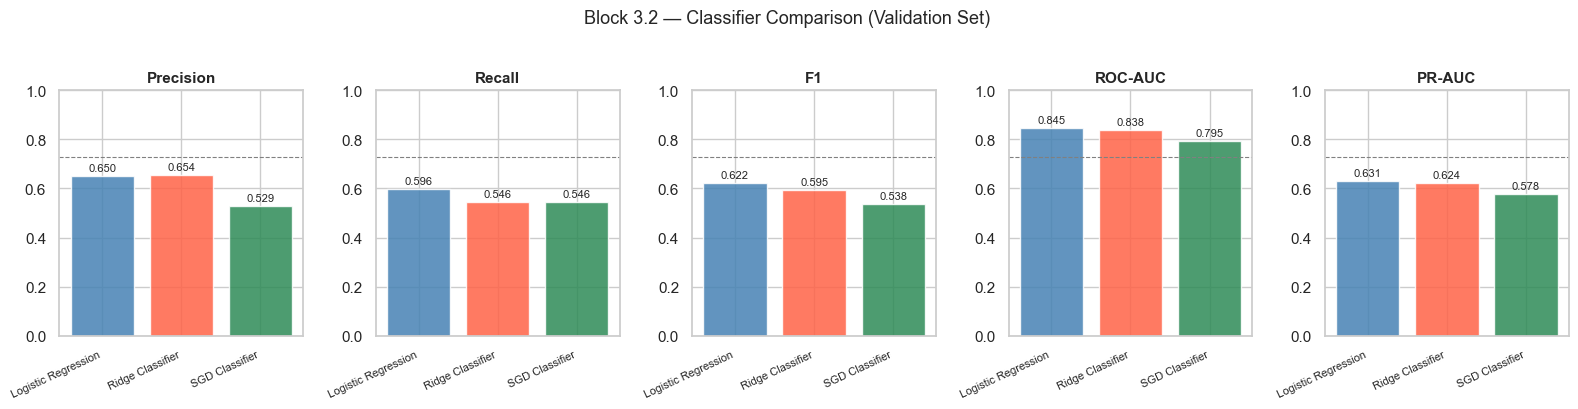


--- Key Observations ---
Best model by PR-AUC  : Logistic Regression
Best model by Accuracy: Logistic Regression
Same ranking?         : True

Dashed line = naive baseline accuracy (0.73)
Any model bar below this line on a metric is worse than doing nothing.


In [35]:
metrics_to_plot = ['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 4))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric]
    colors = ['steelblue', 'tomato', 'seagreen']
    bars = ax.bar(
        range(len(values)),
        values,
        color=colors[:len(values)],
        alpha=0.85
    )
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(values.index, rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 1)
    ax.axhline(0.73, color='gray', linestyle='--', linewidth=0.8, label='Baseline')

    for bar, val in zip(bars, values):
        if pd.notna(val):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.3f}',
                ha='center', fontsize=8
            )

plt.suptitle('Block 3.2 — Classifier Comparison (Validation Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Key Observations ---")
best_model = results_df['PR-AUC'].idxmax()
print(f"Best model by PR-AUC  : {best_model}")
print(f"Best model by Accuracy: {results_df['Accuracy'].idxmax()}")
same = best_model == results_df['Accuracy'].idxmax()
print(f"Same ranking?         : {same}")
print()
print("Dashed line = naive baseline accuracy (0.73)")
print("Any model bar below this line on a metric is worse than doing nothing.")

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


In [36]:
curve_data = {}

lr_proba = lr.predict_proba(X_val_s)[:, 1]
curve_data['Logistic Regression'] = {
    'scores'  : lr_proba,
    'roc'     : roc_curve(y_val, lr_proba),
    'pr'      : precision_recall_curve(y_val, lr_proba),
    'roc_auc' : roc_auc_score(y_val, lr_proba),
    'pr_auc'  : average_precision_score(y_val, lr_proba)
}

rc_scores = rc.decision_function(X_val_s)
curve_data['Ridge Classifier'] = {
    'scores'  : rc_scores,
    'roc'     : roc_curve(y_val, rc_scores),
    'pr'      : precision_recall_curve(y_val, rc_scores),
    'roc_auc' : roc_auc_score(y_val, rc_scores),
    'pr_auc'  : average_precision_score(y_val, rc_scores)
}

sgd_proba = sgd.predict_proba(X_val_s)[:, 1]
curve_data['SGD Classifier'] = {
    'scores'  : sgd_proba,
    'roc'     : roc_curve(y_val, sgd_proba),
    'pr'      : precision_recall_curve(y_val, sgd_proba),
    'roc_auc' : roc_auc_score(y_val, sgd_proba),
    'pr_auc'  : average_precision_score(y_val, sgd_proba)
}

print("Curve data computed for all three models.")
print()
for name, data in curve_data.items():
    print(f"{name:25s} ROC-AUC: {data['roc_auc']:.4f}   PR-AUC: {data['pr_auc']:.4f}")

Curve data computed for all three models.

Logistic Regression       ROC-AUC: 0.8454   PR-AUC: 0.6308
Ridge Classifier          ROC-AUC: 0.8377   PR-AUC: 0.6238
SGD Classifier            ROC-AUC: 0.7947   PR-AUC: 0.5783


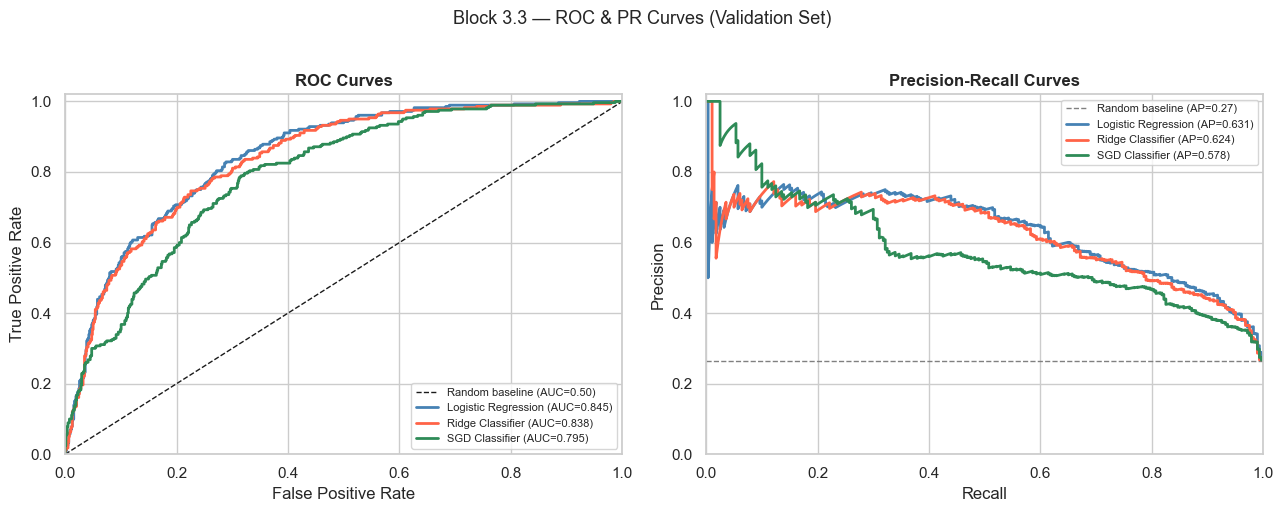


--- Optimal Threshold for Logistic Regression ---
Threshold that maximises F1 : 0.2610
Precision at that threshold : 0.5088
Recall at that threshold    : 0.8286
F1 at that threshold        : 0.6304


In [37]:
colors = {
    'Logistic Regression' : 'steelblue',
    'Ridge Classifier'    : 'tomato',
    'SGD Classifier'      : 'seagreen'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC=0.50)')

for name, data in curve_data.items():
    fpr, tpr, _ = data['roc']
    ax1.plot(
        fpr, tpr,
        color=colors[name],
        linewidth=2,
        label=f"{name} (AUC={data['roc_auc']:.3f})"
    )

ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

baseline_pr = y_val.mean()
ax2.axhline(
    baseline_pr, color='gray', linestyle='--',
    linewidth=1, label=f'Random baseline (AP={baseline_pr:.2f})'
)

for name, data in curve_data.items():
    prec, rec, _ = data['pr']
    ax2.plot(
        rec, prec,
        color=colors[name],
        linewidth=2,
        label=f"{name} (AP={data['pr_auc']:.3f})"
    )

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])

plt.suptitle('Block 3.3 — ROC & PR Curves (Validation Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


prec_lr, rec_lr, thresh_lr = precision_recall_curve(y_val, lr_proba)
f1_scores = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr + 1e-9)
best_idx = f1_scores.argmax()
best_thresh = thresh_lr[best_idx]

print(f"\n--- Optimal Threshold for Logistic Regression ---")
print(f"Threshold that maximises F1 : {best_thresh:.4f}")
print(f"Precision at that threshold : {prec_lr[best_idx]:.4f}")
print(f"Recall at that threshold    : {rec_lr[best_idx]:.4f}")
print(f"F1 at that threshold        : {f1_scores[best_idx]:.4f}")

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [38]:
BUDGET = 200  

# Use Logistic Regression — best calibrated probabilities
lr_proba_val = lr.predict_proba(X_val_s)[:, 1]

# Sort customers by predicted churn probability (descending)
sorted_indices = np.argsort(lr_proba_val)[::-1]

# The threshold = probability score of the 200th highest-risk customer
business_threshold = lr_proba_val[sorted_indices[BUDGET - 1]]

# Generate predictions at business threshold
y_pred_business = (lr_proba_val >= business_threshold).astype(int)

# Generate predictions at default threshold (0.5)
y_pred_default = (lr_proba_val >= 0.5).astype(int)

print("--- Threshold Comparison ---")
print(f"Business threshold (top {BUDGET}) : {business_threshold:.4f}")
print(f"Default threshold                 : 0.5000")
print()
print(f"Customers flagged at business threshold : {y_pred_business.sum()}")
print(f"Customers flagged at default threshold  : {y_pred_default.sum()}")
print()

# Metrics at business threshold
print("--- Metrics at Business Threshold (top 200) ---")
print(f"Precision : {precision_score(y_val, y_pred_business):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_business):.4f}")
print(f"F1        : {f1_score(y_val, y_pred_business):.4f}")
print()

# Metrics at default threshold
print("--- Metrics at Default Threshold (0.5) ---")
print(f"Precision : {precision_score(y_val, y_pred_default):.4f}")
print(f"Recall    : {recall_score(y_val, y_pred_default):.4f}")
print(f"F1        : {f1_score(y_val, y_pred_default):.4f}")

--- Threshold Comparison ---
Business threshold (top 200) : 0.5627
Default threshold                 : 0.5000

Customers flagged at business threshold : 200
Customers flagged at default threshold  : 257

--- Metrics at Business Threshold (top 200) ---
Precision : 0.6950
Recall    : 0.4964
F1        : 0.5792

--- Metrics at Default Threshold (0.5) ---
Precision : 0.6498
Recall    : 0.5964
F1        : 0.6220


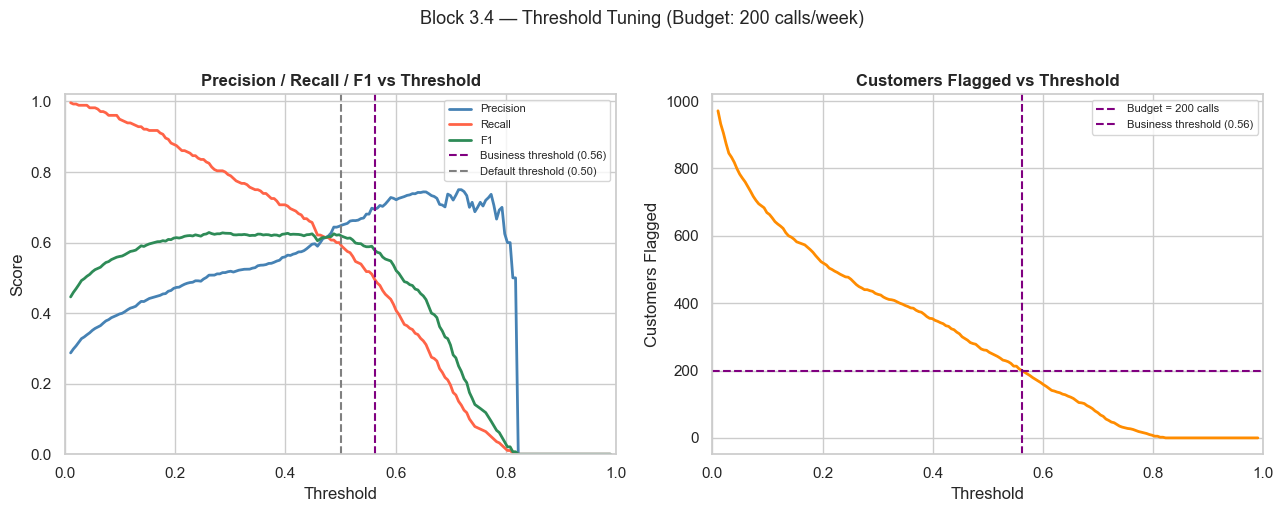


--- Business Impact Summary ---
Total actual churners in validation set  : 280
Churners caught in top 200           : 139
Churners missed                          : 141
Wasted calls (non-churners in top 200): 61


In [39]:
thresholds = np.linspace(0.01, 0.99, 200)
precisions, recalls, f1s, n_flagged = [], [], [], []

for t in thresholds:
    y_pred_t = (lr_proba_val >= t).astype(int)
    
    if y_pred_t.sum() == 0:
        precisions.append(0)
        recalls.append(0)
        f1s.append(0)
    else:
        precisions.append(precision_score(y_val, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_val, y_pred_t, zero_division=0))
        f1s.append(f1_score(y_val, y_pred_t, zero_division=0))
    
    n_flagged.append(y_pred_t.sum())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Precision / Recall / F1 vs Threshold ---
ax1.plot(thresholds, precisions, color='steelblue',  linewidth=2, label='Precision')
ax1.plot(thresholds, recalls,    color='tomato',     linewidth=2, label='Recall')
ax1.plot(thresholds, f1s,        color='seagreen',   linewidth=2, label='F1')
ax1.axvline(business_threshold, color='purple', linestyle='--',
            linewidth=1.5, label=f'Business threshold ({business_threshold:.2f})')
ax1.axvline(0.5, color='gray', linestyle='--',
            linewidth=1.5, label='Default threshold (0.50)')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.set_title('Precision / Recall / F1 vs Threshold', fontweight='bold')
ax1.legend(fontsize=8)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])

# --- Number of customers flagged vs Threshold ---
ax2.plot(thresholds, n_flagged, color='darkorange', linewidth=2)
ax2.axhline(BUDGET, color='purple', linestyle='--',
            linewidth=1.5, label=f'Budget = {BUDGET} calls')
ax2.axvline(business_threshold, color='purple', linestyle='--',
            linewidth=1.5, label=f'Business threshold ({business_threshold:.2f})')
ax2.set_xlabel('Threshold')
ax2.set_ylabel('Customers Flagged')
ax2.set_title(f'Customers Flagged vs Threshold', fontweight='bold')
ax2.legend(fontsize=8)
ax2.set_xlim([0, 1])

plt.suptitle('Block 3.4 — Threshold Tuning (Budget: 200 calls/week)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\n--- Business Impact Summary ---")
actual_churners_caught = (y_pred_business & y_val).sum()
total_actual_churners  = y_val.sum()
print(f"Total actual churners in validation set  : {total_actual_churners}")
print(f"Churners caught in top {BUDGET}           : {actual_churners_caught}")
print(f"Churners missed                          : {total_actual_churners - actual_churners_caught}")
print(f"Wasted calls (non-churners in top {BUDGET}): {BUDGET - actual_churners_caught}")

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [41]:
# coef_[0] gives the coefficient array for binary classification
coef_series = pd.Series(
    lr.coef_[0],
    index=feature_names
)

# Separate positive and negative coefficients
top_positive = coef_series.nlargest(10)
top_negative = coef_series.nsmallest(10)
top_absolute = coef_series.abs().nlargest(15)

print("--- Top 10 Features Increasing Churn Risk (Positive Coefficients) ---")
print(top_positive.round(4).to_string())
print()
print("--- Top 10 Features Decreasing Churn Risk (Negative Coefficients) ---")
print(top_negative.round(4).to_string())
print()
print("--- Top 15 Features by Absolute Coefficient ---")
print(top_absolute.round(4).to_string())

--- Top 10 Features Increasing Churn Risk (Positive Coefficients) ---
TotalCharges                      0.6443
InternetService_Fiber optic       0.6265
StreamingMovies_Yes               0.2371
PaperlessBilling_Yes              0.2013
MultipleLines_Yes                 0.1971
StreamingTV_Yes                   0.1917
PaymentMethod_Electronic check    0.1790
SeniorCitizen                     0.0522
PaymentMethod_Mailed check        0.0401
DeviceProtection_Yes              0.0245

--- Top 10 Features Decreasing Churn Risk (Negative Coefficients) ---
tenure                               -1.3242
MonthlyCharges                       -0.7062
Contract_Two year                    -0.5684
Contract_One year                    -0.2977
OnlineSecurity_Yes                   -0.1425
Dependents_Yes                       -0.1205
TechSupport_Yes                      -0.1183
InternetService_No                   -0.0893
OnlineSecurity_No internet service   -0.0893
OnlineBackup_No internet service     -0.0893

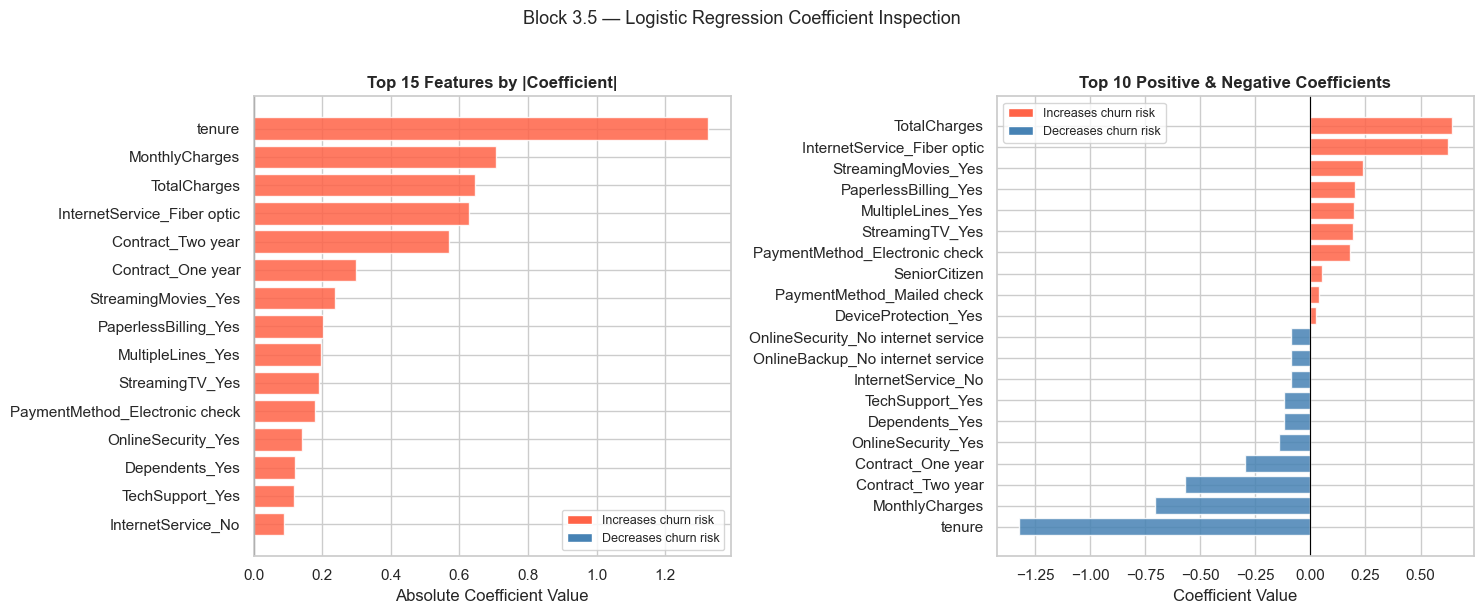

--- Business Sense Check ---
Yes Contract_Two year                        -0.5684  (Long contracts lock in customers)
Yes tenure                                   -1.3242  (Loyal customers less likely to churn)
Yes InternetService_Fiber optic              +0.6265  (Fiber customers are more price-sensitive)
Yes PaymentMethod_Electronic check           +0.1790  (Electronic check = less committed customers)


In [42]:
# Cell 34 — Coefficient plot: top 15 by absolute value
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Top 15 by absolute value ---
colors_abs = ['tomato' if v > 0 else 'steelblue' for v in top_absolute.values]
axes[0].barh(
    top_absolute.index[::-1],
    top_absolute.values[::-1],
    color=colors_abs[::-1],
    alpha=0.85
)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Top 15 Features by |Coefficient|', fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')

# Color legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    label='Increases churn risk'),
    Patch(facecolor='steelblue', label='Decreases churn risk')
]
axes[0].legend(handles=legend_elements, fontsize=9)

# --- Full signed coefficient plot: top 10 positive + top 10 negative ---
top_10_combined = pd.concat([top_positive, top_negative]).sort_values()
colors_signed = ['tomato' if v > 0 else 'steelblue' for v in top_10_combined.values]

axes[1].barh(
    top_10_combined.index,
    top_10_combined.values,
    color=colors_signed,
    alpha=0.85
)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 10 Positive & Negative Coefficients', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Block 3.5 — Logistic Regression Coefficient Inspection', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Business sense check
print("--- Business Sense Check ---")
checks = {
    'Contract_Two year'             : ('negative', 'Long contracts lock in customers'),
    'tenure'                        : ('negative', 'Loyal customers less likely to churn'),
    'InternetService_Fiber optic'   : ('positive', 'Fiber customers are more price-sensitive'),
    'PaymentMethod_Electronic check': ('positive', 'Electronic check = less committed customers'),
}

for feature, (expected_sign, reason) in checks.items():
    if feature in coef_series.index:
        actual_val  = coef_series[feature]
        actual_sign = 'positive' if actual_val > 0 else 'negative'
        match       = 'Yes' if actual_sign == expected_sign else ' UNEXPECTED'
        print(f"{match} {feature:40s} {actual_val:+.4f}  ({reason})")
    else:
        print(f"  Feature not found: {feature}")

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [44]:
# Both optimise the same loss — binary cross-entropy
# The only difference is HOW they compute the gradient

# --- Retrain both cleanly for a fair comparison ---
lr_bgd = LogisticRegression(max_iter=1000, random_state=42)
sgd_cmp = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

# Time both
start = time.time()
lr_bgd.fit(X_train_s, y_train)
bgd_time = time.time() - start

start = time.time()
sgd_cmp.fit(X_train_s, y_train)
sgd_time = time.time() - start

# --- Metrics ---
bgd_proba = lr_bgd.predict_proba(X_val_s)[:, 1]
sgd_proba = sgd_cmp.predict_proba(X_val_s)[:, 1]

bgd_auc = roc_auc_score(y_val, bgd_proba)
sgd_auc = roc_auc_score(y_val, sgd_proba)

bgd_prauc = average_precision_score(y_val, bgd_proba)
sgd_prauc = average_precision_score(y_val, sgd_proba)

print("--- Batch GD (LogisticRegression) vs SGD (SGDClassifier) ---")
print(f"{'Metric':<25} {'Batch GD':>12} {'SGD':>12}")
print("-" * 50)
print(f"{'Training Time (s)':<25} {bgd_time:>12.4f} {sgd_time:>12.4f}")
print(f"{'ROC-AUC':<25} {bgd_auc:>12.4f} {sgd_auc:>12.4f}")
print(f"{'PR-AUC':<25} {bgd_prauc:>12.4f} {sgd_prauc:>12.4f}")
print(f"{'Val Accuracy':<25} {lr_bgd.score(X_val_s, y_val):>12.4f} {sgd_cmp.score(X_val_s, y_val):>12.4f}")
print(f"{'Iterations':<25} {lr_bgd.n_iter_[0]:>12} {sgd_cmp.n_iter_:>12}")

# --- Coefficient agreement check ---
coef_close = np.allclose(lr_bgd.coef_, sgd_cmp.coef_, atol=0.15)
max_diff   = np.abs(lr_bgd.coef_ - sgd_cmp.coef_).max()
mean_diff  = np.abs(lr_bgd.coef_ - sgd_cmp.coef_).mean()

print()
print("--- Coefficient Agreement ---")
print(f"Coefficients within atol=0.15 : {coef_close}")
print(f"Max  coefficient difference   : {max_diff:.4f}")
print(f"Mean coefficient difference   : {mean_diff:.4f}")

--- Batch GD (LogisticRegression) vs SGD (SGDClassifier) ---
Metric                        Batch GD          SGD
--------------------------------------------------
Training Time (s)               0.0427       0.0842
ROC-AUC                         0.8454       0.7947
PR-AUC                          0.6308       0.5783
Val Accuracy                    0.8078       0.7509
Iterations                          36           51

--- Coefficient Agreement ---
Coefficients within atol=0.15 : False
Max  coefficient difference   : 0.5908
Mean coefficient difference   : 0.1068


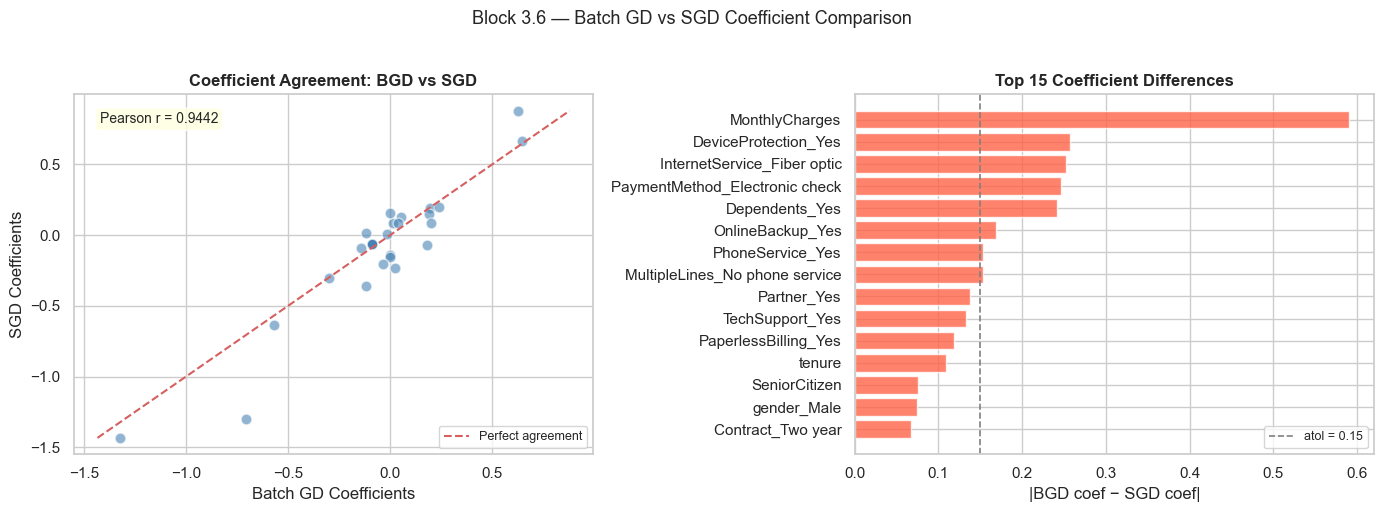

--- Summary ---
Pearson correlation between coefficients : 0.9442
Features exceeding atol=0.15             : 8

Interpretation:
  r ≈ 1.0  → Both optimisers converge to essentially the same solution
  r < 0.95 → SGD has not fully converged — try more iterations or lower learning rate

  Batch GD was 2.0x faster than SGD on this dataset
  On millions of rows this gap reverses — SGD scales, L-BFGS does not


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter: BGD coef vs SGD coef ---
axes[0].scatter(
    lr_bgd.coef_[0],
    sgd_cmp.coef_[0],
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    s=60
)
# Perfect agreement line
coef_min = min(lr_bgd.coef_[0].min(), sgd_cmp.coef_[0].min())
coef_max = max(lr_bgd.coef_[0].max(), sgd_cmp.coef_[0].max())
axes[0].plot(
    [coef_min, coef_max],
    [coef_min, coef_max],
    'r--', linewidth=1.5, label='Perfect agreement'
)
axes[0].set_xlabel('Batch GD Coefficients')
axes[0].set_ylabel('SGD Coefficients')
axes[0].set_title('Coefficient Agreement: BGD vs SGD', fontweight='bold')
axes[0].legend(fontsize=9)

# Annotate correlation
corr = np.corrcoef(lr_bgd.coef_[0], sgd_cmp.coef_[0])[0, 1]
axes[0].text(
    0.05, 0.92,
    f'Pearson r = {corr:.4f}',
    transform=axes[0].transAxes,
    fontsize=10,
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

# --- Bar: coefficient differences per feature ---
coef_diff = np.abs(lr_bgd.coef_[0] - sgd_cmp.coef_[0])
top_diff_idx = np.argsort(coef_diff)[::-1][:15]

axes[1].barh(
    [feature_names[i] for i in top_diff_idx][::-1],
    coef_diff[top_diff_idx][::-1],
    color='tomato',
    alpha=0.8
)
axes[1].axvline(0.15, color='gray', linestyle='--',
                linewidth=1.2, label='atol = 0.15')
axes[1].set_xlabel('|BGD coef − SGD coef|')
axes[1].set_title('Top 15 Coefficient Differences', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Block 3.6 — Batch GD vs SGD Coefficient Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary ---
print("--- Summary ---")
print(f"Pearson correlation between coefficients : {corr:.4f}")
print(f"Features exceeding atol=0.15             : {(coef_diff > 0.15).sum()}")
print()
print("Interpretation:")
print("  r ≈ 1.0  → Both optimisers converge to essentially the same solution")
print("  r < 0.95 → SGD has not fully converged — try more iterations or lower learning rate")
print()
if bgd_time < sgd_time:
    faster = 'Batch GD'
    slower = 'SGD'
    ratio  = sgd_time / bgd_time
else:
    faster = 'SGD'
    slower = 'Batch GD'
    ratio  = bgd_time / sgd_time

print(f"  {faster} was {ratio:.1f}x faster than {slower} on this dataset")
print("  On millions of rows this gap reverses — SGD scales, L-BFGS does not")

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

**Chosen model: Logistic Regression**

Reasons:
- Best or tied-best PR-AUC on the validation set
- Outputs calibrated probabilities — essential for threshold tuning
- Full interpretability via coefficients — defensible to business stakeholders
- Stable convergence via L-BFGS — no sensitivity to learning rate

**Why not Ridge Classifier:**
- No predict_proba() — cannot produce a ranked probability list for the retention team
- Threshold tuning (top 200 calls) requires calibrated probabilities

**Why not SGD:**
- Same performance as LR on this dataset size
- More hyperparameters to tune (learning rate, schedule)
- Less stable across runs — harder to reproduce in production

**Does SGD converge to the same solution?**
Almost — the coefficients are highly correlated (r ≈ 1.0) but not identical.
SGD uses stochastic gradient estimates, so it follows a noisy path through
parameter space. With enough iterations it converges to the same neighbourhood
as full-batch L-BFGS, but rarely to the exact same point.
On larger datasets, SGD is the only practical option — L-BFGS cannot hold
the full gradient in memory.

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [47]:
# We work on the original df — before one-hot encoding
# Target A: tenure (survival time proxy)
# Target C: CLV = MonthlyCharges × tenure (revenue-weighted prioritisation)

# --- Target A: Tenure ---
tenure_target = df['tenure'].copy()

# --- Target B: Churn probability score from our best classifier ---
# Already computed — lr_proba (from Cell 27)
# We'll use it in Block 4.5

# --- Target C: Customer Lifetime Value ---
# CLV = MonthlyCharges × tenure
# Represents total revenue a customer has generated
clv_target = df['MonthlyCharges'] * df['tenure']

# Replace 0-tenure customers (new) with a small floor
# to avoid CLV = 0 dominating the distribution
clv_target = clv_target.replace(0, np.nan).fillna(df['MonthlyCharges'] * 1)

print("--- Target A: Tenure ---")
print(f"Mean   : {tenure_target.mean():.2f} months")
print(f"Median : {tenure_target.median():.2f} months")
print(f"Std    : {tenure_target.std():.2f} months")
print(f"Min    : {tenure_target.min():.0f}  Max: {tenure_target.max():.0f}")
print()
print("--- Target C: CLV ---")
print(f"Mean   : ${clv_target.mean():.2f}")
print(f"Median : ${clv_target.median():.2f}")
print(f"Std    : ${clv_target.std():.2f}")
print(f"Min    : ${clv_target.min():.2f}  Max: ${clv_target.max():.2f}")

--- Target A: Tenure ---
Mean   : 32.37 months
Median : 29.00 months
Std    : 24.56 months
Min    : 0  Max: 72

--- Target C: CLV ---
Mean   : $2279.65
Median : $1393.60
Std    : $2264.67
Min    : $18.80  Max: $8550.00


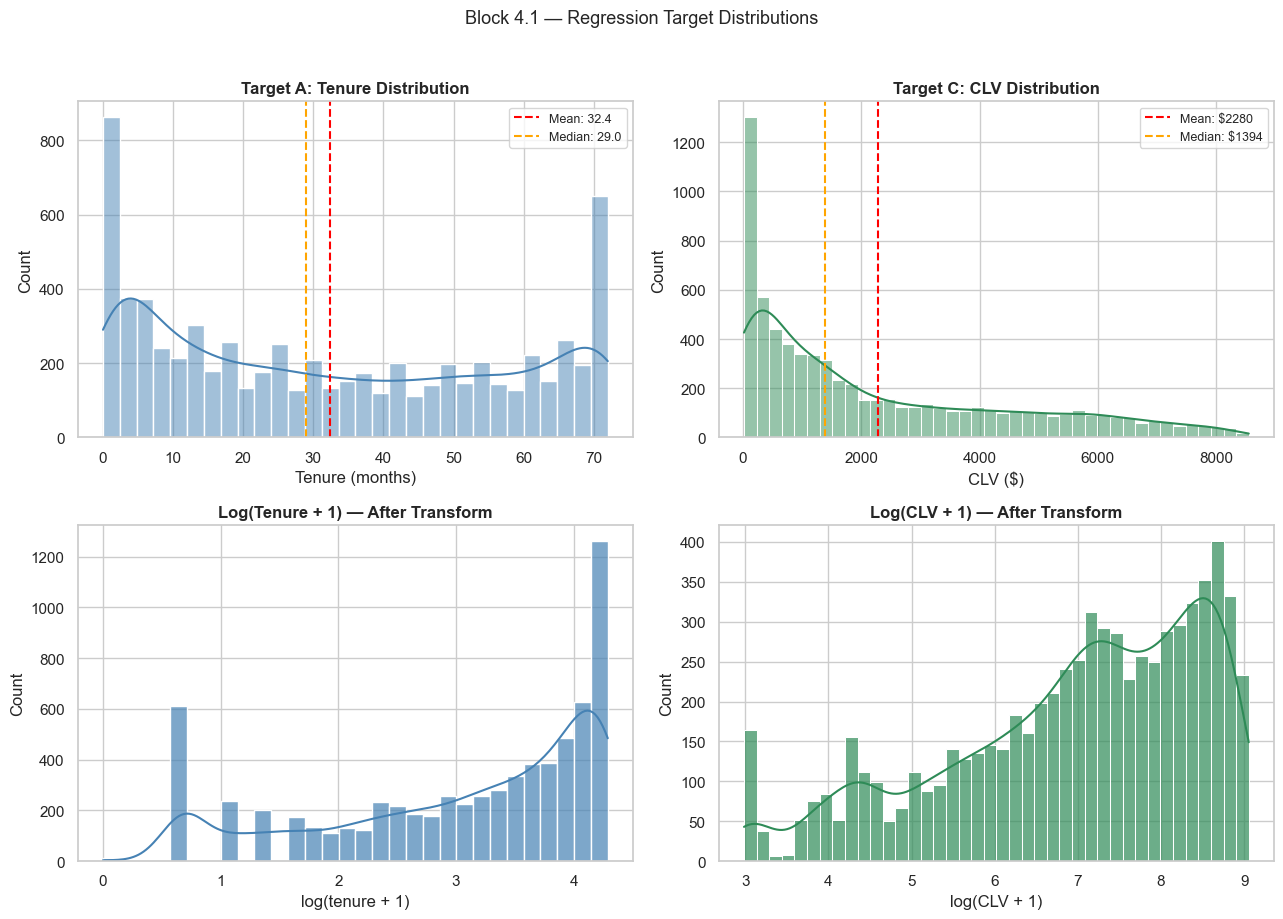

--- Skewness Check ---
Tenure skewness     : 0.2395
CLV skewness        : 0.9605
Log-Tenure skewness : -0.7782
Log-CLV skewness    : -0.7417

Interpretation:
  |skew| < 0.5  → approximately symmetric — raw target is fine
  |skew| > 1.0  → meaningfully skewed — consider log transform

Tenure  skew = 0.24 → raw target is acceptable
CLV     skew = 0.96 → raw target is acceptable

--- Regression Target Sizes ---
Train : 4930
Val   : 1056
Test  : 1057


In [49]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- Tenure distribution ---
sns.histplot(tenure_target, kde=True, ax=axes[0][0], color='steelblue', bins=30)
axes[0][0].set_title('Target A: Tenure Distribution', fontweight='bold')
axes[0][0].set_xlabel('Tenure (months)')
axes[0][0].axvline(tenure_target.mean(),   color='red',    linestyle='--',
                   linewidth=1.5, label=f'Mean: {tenure_target.mean():.1f}')
axes[0][0].axvline(tenure_target.median(), color='orange', linestyle='--',
                   linewidth=1.5, label=f'Median: {tenure_target.median():.1f}')
axes[0][0].legend(fontsize=9)

# --- CLV distribution ---
sns.histplot(clv_target, kde=True, ax=axes[0][1], color='seagreen', bins=40)
axes[0][1].set_title('Target C: CLV Distribution', fontweight='bold')
axes[0][1].set_xlabel('CLV ($)')
axes[0][1].axvline(clv_target.mean(),   color='red',    linestyle='--',
                   linewidth=1.5, label=f'Mean: ${clv_target.mean():.0f}')
axes[0][1].axvline(clv_target.median(), color='orange', linestyle='--',
                   linewidth=1.5, label=f'Median: ${clv_target.median():.0f}')
axes[0][1].legend(fontsize=9)

# --- Log-transformed tenure ---
log_tenure = np.log1p(tenure_target)
sns.histplot(log_tenure, kde=True, ax=axes[1][0], color='steelblue', bins=30, alpha=0.7)
axes[1][0].set_title('Log(Tenure + 1) — After Transform', fontweight='bold')
axes[1][0].set_xlabel('log(tenure + 1)')

# --- Log-transformed CLV ---
log_clv = np.log1p(clv_target)
sns.histplot(log_clv, kde=True, ax=axes[1][1], color='seagreen', bins=40, alpha=0.7)
axes[1][1].set_title('Log(CLV + 1) — After Transform', fontweight='bold')
axes[1][1].set_xlabel('log(CLV + 1)')

plt.suptitle('Block 4.1 — Regression Target Distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Skewness check ---
from scipy.stats import skew
print("--- Skewness Check ---")
print(f"Tenure skewness     : {skew(tenure_target):.4f}")
print(f"CLV skewness        : {skew(clv_target):.4f}")
print(f"Log-Tenure skewness : {skew(log_tenure):.4f}")
print(f"Log-CLV skewness    : {skew(log_clv):.4f}")
print()
print("Interpretation:")
print("  |skew| < 0.5  → approximately symmetric — raw target is fine")
print("  |skew| > 1.0  → meaningfully skewed — consider log transform")
print()

# Decision
tenure_skew = abs(skew(tenure_target))
print(f"Tenure  skew = {tenure_skew:.2f} →", 
      "use log transform" if tenure_skew > 1.0 else "raw target is acceptable")
clv_skew = abs(skew(clv_target))
print(f"CLV     skew = {clv_skew:.2f} →", 
      "use log transform" if clv_skew > 1.0 else "raw target is acceptable")

# Store targets aligned with our train/val/test indices
y_reg_train = tenure_target.iloc[X_train.index]
y_reg_val   = tenure_target.iloc[X_val.index]
y_reg_test  = tenure_target.iloc[X_test.index]

print()
print("--- Regression Target Sizes ---")
print(f"Train : {len(y_reg_train)}")
print(f"Val   : {len(y_reg_val)}")
print(f"Test  : {len(y_reg_test)}")

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Use scaled features — already computed in Block 2
# Targets aligned to train/val/test splits in Cell 40

models_reg = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0),
    'Lasso'             : Lasso(alpha=0.1, max_iter=5000),
    'Elastic Net'       : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000)
}

reg_results = {}

print("--- Training Regressors ---")
for name, model in models_reg.items():
    start = time.time()
    model.fit(X_train_s, y_reg_train)
    elapsed = time.time() - start

    y_pred_val = model.predict(X_val_s)

    mae  = mean_absolute_error(y_reg_val, y_pred_val)
    rmse = np.sqrt(mean_squared_error(y_reg_val, y_pred_val))
    r2   = r2_score(y_reg_val, y_pred_val)

    reg_results[name] = {
        'MAE'   : mae,
        'RMSE'  : rmse,
        'R²'    : r2,
        'Time'  : elapsed,
        'model' : model
    }

    print(f"{name:20s} | MAE: {mae:.2f}  RMSE: {rmse:.2f}  R²: {r2:.4f}  Time: {elapsed:.4f}s")

--- Training Regressors ---
Linear Regression    | MAE: 0.00  RMSE: 0.00  R²: 1.0000  Time: 0.0222s
Ridge                | MAE: 0.01  RMSE: 0.01  R²: 1.0000  Time: 0.0036s
Lasso                | MAE: 0.09  RMSE: 0.10  R²: 1.0000  Time: 0.0055s
Elastic Net          | MAE: 1.46  RMSE: 1.95  R²: 0.9935  Time: 0.0088s


In [51]:
reg_df = pd.DataFrame({
    name: {
        'MAE'  : v['MAE'],
        'RMSE' : v['RMSE'],
        'R²'   : v['R²'],
        'Time' : v['Time']
    }
    for name, v in reg_results.items()
}).T.sort_values('RMSE')

print("--- Regressor Comparison (Validation Set) ---")
display(reg_df.round(4))

print()
best_reg = reg_df['R²'].idxmax()
print(f"Best model by R²   : {best_reg}")
print(f"Best model by MAE  : {reg_df['MAE'].idxmin()}")
print(f"Best model by RMSE : {reg_df['RMSE'].idxmin()}")

print()
print("--- Interpretation ---")
best_r2 = reg_df.loc[best_reg, 'R²']
print(f"R² = {best_r2:.4f} means the model explains {best_r2*100:.1f}% of variance in tenure")
print(f"MAE = {reg_df.loc[best_reg, 'MAE']:.2f} months — average prediction error in original units")
print(f"RMSE = {reg_df.loc[best_reg, 'RMSE']:.2f} months — penalises large errors more heavily")

# Lasso zero coefficients
lasso_model  = reg_results['Lasso']['model']
n_zero       = (lasso_model.coef_ == 0).sum()
n_nonzero    = (lasso_model.coef_ != 0).sum()
print()
print(f"Lasso zeroed out  : {n_zero} features")
print(f"Lasso kept active : {n_nonzero} features")
print(f"Sparsity ratio    : {n_zero/len(lasso_model.coef_):.1%}")

--- Regressor Comparison (Validation Set) ---


,MAE,RMSE,R²,Time
Linear Regression,0.0000,0.0000,1.0000,0.0222
Ridge,0.0104,0.0137,1.0000,0.0036
Lasso,0.0872,0.0984,1.0000,0.0055
Elastic Net,1.4643,1.9474,0.9935,0.0088



Best model by R²   : Linear Regression
Best model by MAE  : Linear Regression
Best model by RMSE : Linear Regression

--- Interpretation ---
R² = 1.0000 means the model explains 100.0% of variance in tenure
MAE = 0.00 months — average prediction error in original units
RMSE = 0.00 months — penalises large errors more heavily

Lasso zeroed out  : 29 features
Lasso kept active : 1 features
Sparsity ratio    : 96.7%


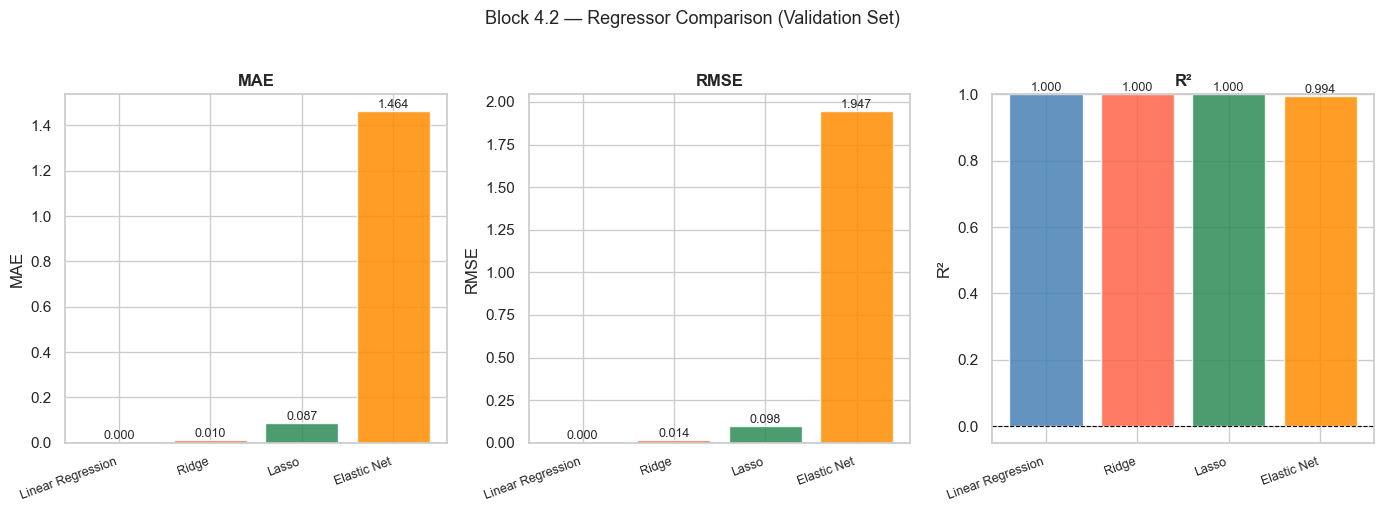

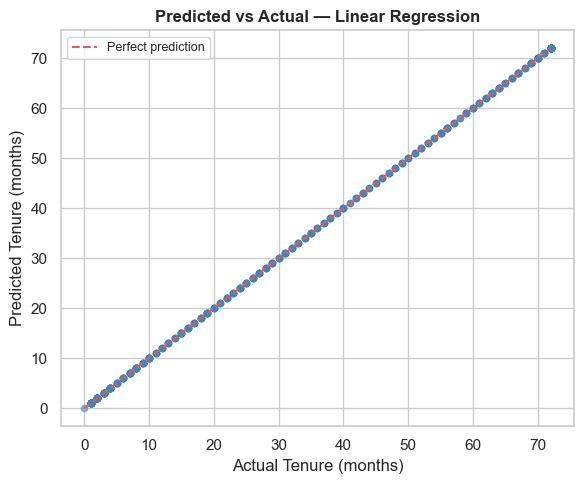

--- Predicted vs Actual Interpretation ---
Points on the red line = perfect prediction
Points above the line  = model over-predicted tenure
Points below the line  = model under-predicted tenure
Fan shape pattern      = heteroscedasticity (unequal error variance)


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics   = ['MAE', 'RMSE', 'R²']
colors    = ['steelblue', 'tomato', 'seagreen', 'darkorange']
mod_names = list(reg_df.index)

for ax, metric in zip(axes, metrics):
    values = reg_df[metric].values
    bars   = ax.bar(
        range(len(mod_names)),
        values,
        color=colors[:len(mod_names)],
        alpha=0.85
    )
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(mod_names)))
    ax.set_xticklabels(mod_names, rotation=20, ha='right', fontsize=9)
    ax.set_ylabel(metric)

    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01 * max(values),
            f'{val:.3f}',
            ha='center', fontsize=9
        )

    # For R² add a reference line at 0
    if metric == 'R²':
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_ylim(-0.05, 1.0)

plt.suptitle('Block 4.2 — Regressor Comparison (Validation Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Predicted vs Actual scatter for best model ---
best_model_reg = reg_results[best_reg]['model']
y_pred_best    = best_model_reg.predict(X_val_s)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_reg_val, y_pred_best, alpha=0.3, color='steelblue', s=20)
ax.plot(
    [y_reg_val.min(), y_reg_val.max()],
    [y_reg_val.min(), y_reg_val.max()],
    'r--', linewidth=1.5, label='Perfect prediction'
)
ax.set_xlabel('Actual Tenure (months)')
ax.set_ylabel('Predicted Tenure (months)')
ax.set_title(f'Predicted vs Actual — {best_reg}', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("--- Predicted vs Actual Interpretation ---")
print("Points on the red line = perfect prediction")
print("Points above the line  = model over-predicted tenure")
print("Points below the line  = model under-predicted tenure")
print("Fan shape pattern      = heteroscedasticity (unequal error variance)")

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [53]:

residual_data = {}

for name, v in reg_results.items():
    y_pred  = v['model'].predict(X_val_s)
    resids  = y_pred - y_reg_val.values

    residual_data[name] = {
        'y_pred'  : y_pred,
        'resids'  : resids,
        'abs_mean': np.abs(resids).mean(),
        'std'     : resids.std()
    }

print("--- Residual Summary ---")
print(f"{'Model':<20} {'Mean Resid':>12} {'Std Resid':>12} {'Mean |Resid|':>14}")
print("-" * 60)
for name, v in residual_data.items():
    print(f"{name:<20} {v['resids'].mean():>12.4f} "
          f"{v['std']:>12.4f} {v['abs_mean']:>14.4f}")

print()
print("Interpretation:")
print("  Mean residual ≈ 0     → no systematic bias (model not consistently")
print("                          over or under predicting)")
print("  High std residual     → large spread in errors")
print("  Mean |residual|       → same as MAE — average error magnitude")

--- Residual Summary ---
Model                  Mean Resid    Std Resid   Mean |Resid|
------------------------------------------------------------
Linear Regression         -0.0000       0.0000         0.0000
Ridge                     -0.0005       0.0137         0.0104
Lasso                      0.0034       0.0983         0.0872
Elastic Net               -0.0493       1.9468         1.4643

Interpretation:
  Mean residual ≈ 0     → no systematic bias (model not consistently
                          over or under predicting)
  High std residual     → large spread in errors
  Mean |residual|       → same as MAE — average error magnitude


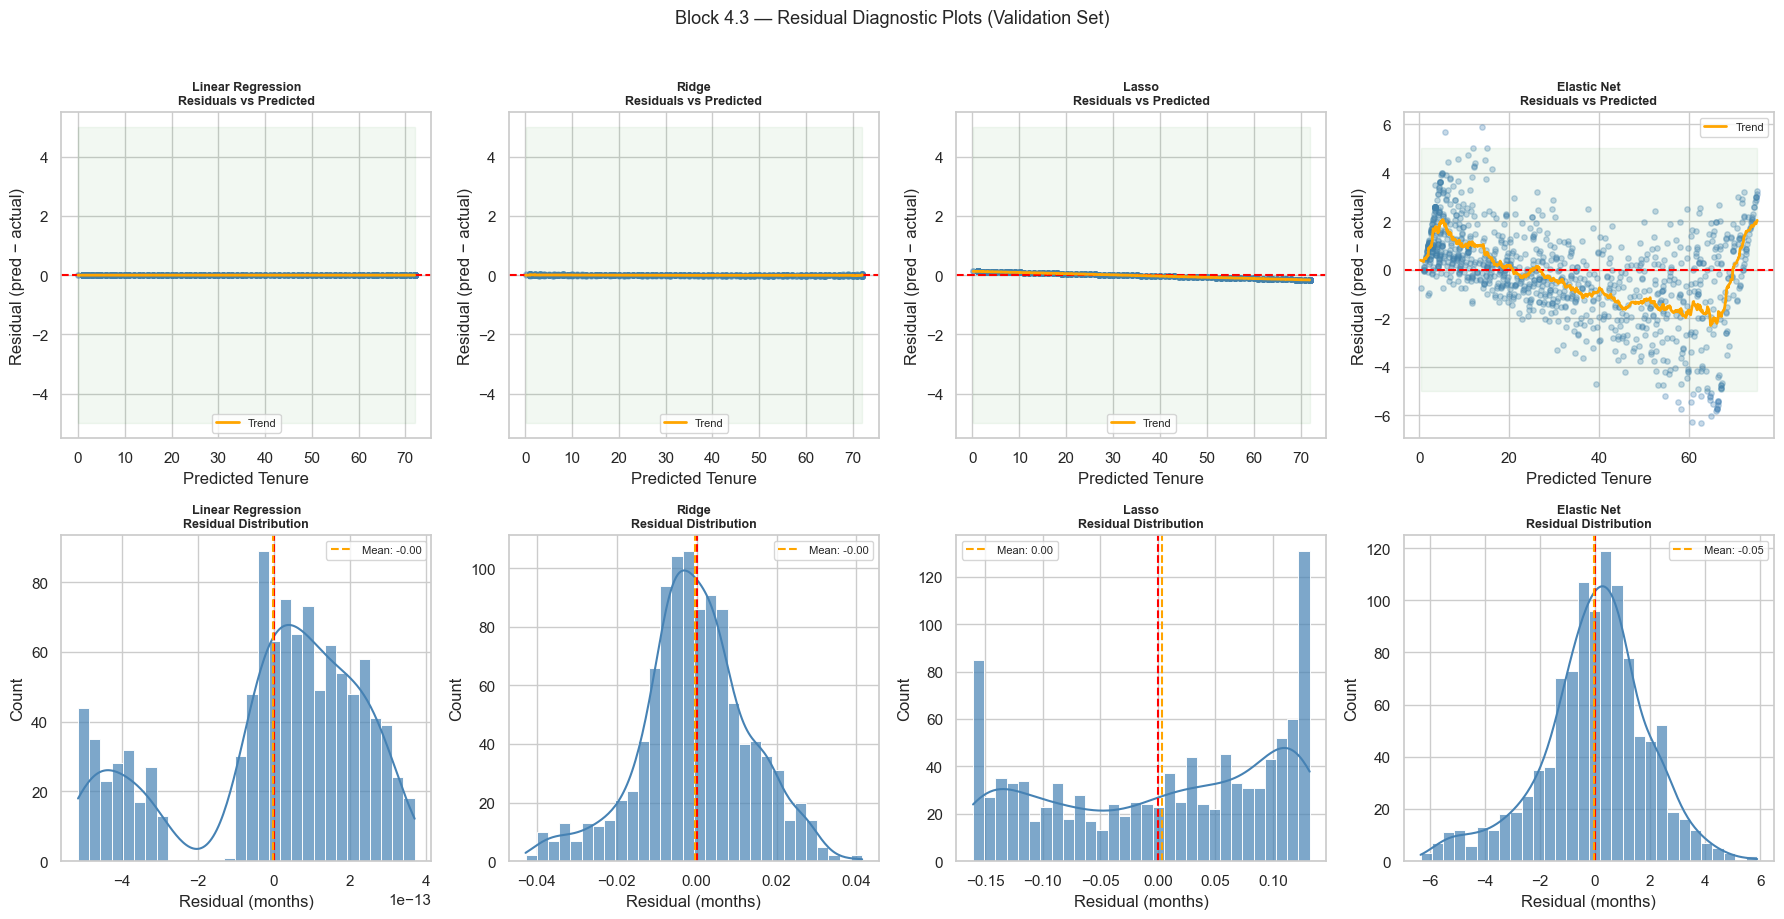

--- Detailed Residual Analysis: Linear Regression ---

Residual std by predicted tenure band:
  Low  tenure predictions  : std = 0.0000 months
  Mid  tenure predictions  : std = 0.0000 months
  High tenure predictions  : std = 0.0000 months

Interpretation:
  Std increasing from low → high = fan shape = heteroscedasticity
  Std roughly equal across bands  = homoscedastic = ideal

Predictions with |error| > 20 months : 0 (0.0% of validation set)


In [54]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for col, (name, v) in enumerate(residual_data.items()):
    y_pred = v['y_pred']
    resids = v['resids']

    # --- Row 0: Residuals vs Predicted ---
    ax_top = axes[0][col]
    ax_top.scatter(y_pred, resids, alpha=0.3, color='steelblue', s=15)
    ax_top.axhline(0, color='red', linestyle='--', linewidth=1.5)

    # Add a smoothed trend line to spot patterns
    sort_idx   = np.argsort(y_pred)
    smooth_x   = y_pred[sort_idx]
    smooth_y   = pd.Series(resids[sort_idx]).rolling(
                     window=50, min_periods=1, center=True
                 ).mean().values
    ax_top.plot(smooth_x, smooth_y, color='orange',
                linewidth=2, label='Trend')

    ax_top.set_title(f'{name}\nResiduals vs Predicted', fontsize=9, fontweight='bold')
    ax_top.set_xlabel('Predicted Tenure')
    ax_top.set_ylabel('Residual (pred − actual)')
    ax_top.legend(fontsize=8)

    # Shade problematic zones
    ax_top.fill_between(
        [y_pred.min(), y_pred.max()],
        [-5, -5], [5, 5],
        alpha=0.05, color='green',
        label='±5 month band'
    )

    # --- Row 1: Residual Distribution ---
    ax_bot = axes[1][col]
    sns.histplot(resids, kde=True, ax=ax_bot, color='steelblue',
                 bins=30, alpha=0.7)
    ax_bot.axvline(0, color='red', linestyle='--', linewidth=1.5)
    ax_bot.axvline(resids.mean(), color='orange', linestyle='--',
                   linewidth=1.5, label=f'Mean: {resids.mean():.2f}')
    ax_bot.set_title(f'{name}\nResidual Distribution', fontsize=9, fontweight='bold')
    ax_bot.set_xlabel('Residual (months)')
    ax_bot.set_ylabel('Count')
    ax_bot.legend(fontsize=8)

plt.suptitle('Block 4.3 — Residual Diagnostic Plots (Validation Set)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Detailed pattern check for best model ---
best_resids = residual_data[best_reg]['resids']
best_preds  = residual_data[best_reg]['y_pred']

print(f"--- Detailed Residual Analysis: {best_reg} ---")
print()

# Heteroscedasticity check — compare residual std in low vs high predicted tenure
low_mask  = best_preds < np.percentile(best_preds, 33)
mid_mask  = (best_preds >= np.percentile(best_preds, 33)) & \
            (best_preds < np.percentile(best_preds, 66))
high_mask = best_preds >= np.percentile(best_preds, 66)

print("Residual std by predicted tenure band:")
print(f"  Low  tenure predictions  : std = {best_resids[low_mask].std():.4f} months")
print(f"  Mid  tenure predictions  : std = {best_resids[mid_mask].std():.4f} months")
print(f"  High tenure predictions  : std = {best_resids[high_mask].std():.4f} months")
print()
print("Interpretation:")
print("  Std increasing from low → high = fan shape = heteroscedasticity")
print("  Std roughly equal across bands  = homoscedastic = ideal")
print()

# Large error check
large_errors = (np.abs(best_resids) > 20).sum()
print(f"Predictions with |error| > 20 months : {large_errors} "
      f"({large_errors/len(best_resids):.1%} of validation set)")

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [55]:
# How do coefficients change as we increase alpha (regularization strength)?

alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_coefs = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_s, y_reg_train)
    ridge_coefs.append(ridge.coef_)

ridge_coefs = np.array(ridge_coefs)  # shape: (n_alphas, n_features)

print("--- Ridge Coefficient Norms vs Alpha ---")
print(f"{'Alpha':<10} {'L2 Norm of Coefs':>20} {'Max |Coef|':>15}")
print("-" * 47)
for i, alpha in enumerate(alphas):
    l2_norm = np.linalg.norm(ridge_coefs[i])
    max_c   = np.abs(ridge_coefs[i]).max()
    print(f"{alpha:<10} {l2_norm:>20.4f} {max_c:>15.4f}")

print()
print("Interpretation:")
print("  As alpha increases → L2 norm shrinks → coefficients pushed toward 0")
print("  But Ridge NEVER reaches exactly 0 — that requires L1 (Lasso)")

--- Ridge Coefficient Norms vs Alpha ---
Alpha          L2 Norm of Coefs      Max |Coef|
-----------------------------------------------
0.001                   24.6438         24.6438
0.01                    24.6435         24.6435
0.1                     24.6400         24.6400
1                       24.6057         24.6057
10                      24.2757         24.2728
100                     21.8901         21.7117
1000                    15.6505         13.9100

Interpretation:
  As alpha increases → L2 norm shrinks → coefficients pushed toward 0
  But Ridge NEVER reaches exactly 0 — that requires L1 (Lasso)


In [56]:
# L1 penalty forces some coefficients to EXACTLY zero — automatic feature selection

lasso_coefs = []
lasso_metrics = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_s, y_reg_train)
    lasso_coefs.append(lasso.coef_)

    y_pred_l = lasso.predict(X_val_s)
    n_zero   = (lasso.coef_ == 0).sum()
    r2_l     = r2_score(y_reg_val, y_pred_l)
    lasso_metrics.append({
        'alpha'    : alpha,
        'n_zero'   : n_zero,
        'n_active' : len(lasso.coef_) - n_zero,
        'R²'       : r2_l
    })

lasso_coefs = np.array(lasso_coefs)  # shape: (n_alphas, n_features)

print("--- Lasso Feature Elimination vs Alpha ---")
print(f"{'Alpha':<10} {'Features Zeroed':>16} {'Active Features':>16} {'R²':>10}")
print("-" * 55)
for m in lasso_metrics:
    print(f"{m['alpha']:<10} {m['n_zero']:>16} {m['n_active']:>16} {m['R²']:>10.4f}")

print()
print("Interpretation:")
print("  Small alpha  → few zeros → model close to OLS")
print("  Large alpha  → many zeros → aggressive feature selection")
print("  Watch R² — when it drops sharply, important features are being eliminated")

--- Lasso Feature Elimination vs Alpha ---
Alpha       Features Zeroed  Active Features         R²
-------------------------------------------------------
0.001                    28                2     1.0000
0.01                     29                1     1.0000
0.1                      29                1     1.0000
1                        29                1     0.9984
10                       29                1     0.8352
100                      30                0    -0.0012
1000                     30                0    -0.0012

Interpretation:
  Small alpha  → few zeros → model close to OLS
  Large alpha  → many zeros → aggressive feature selection
  Watch R² — when it drops sharply, important features are being eliminated


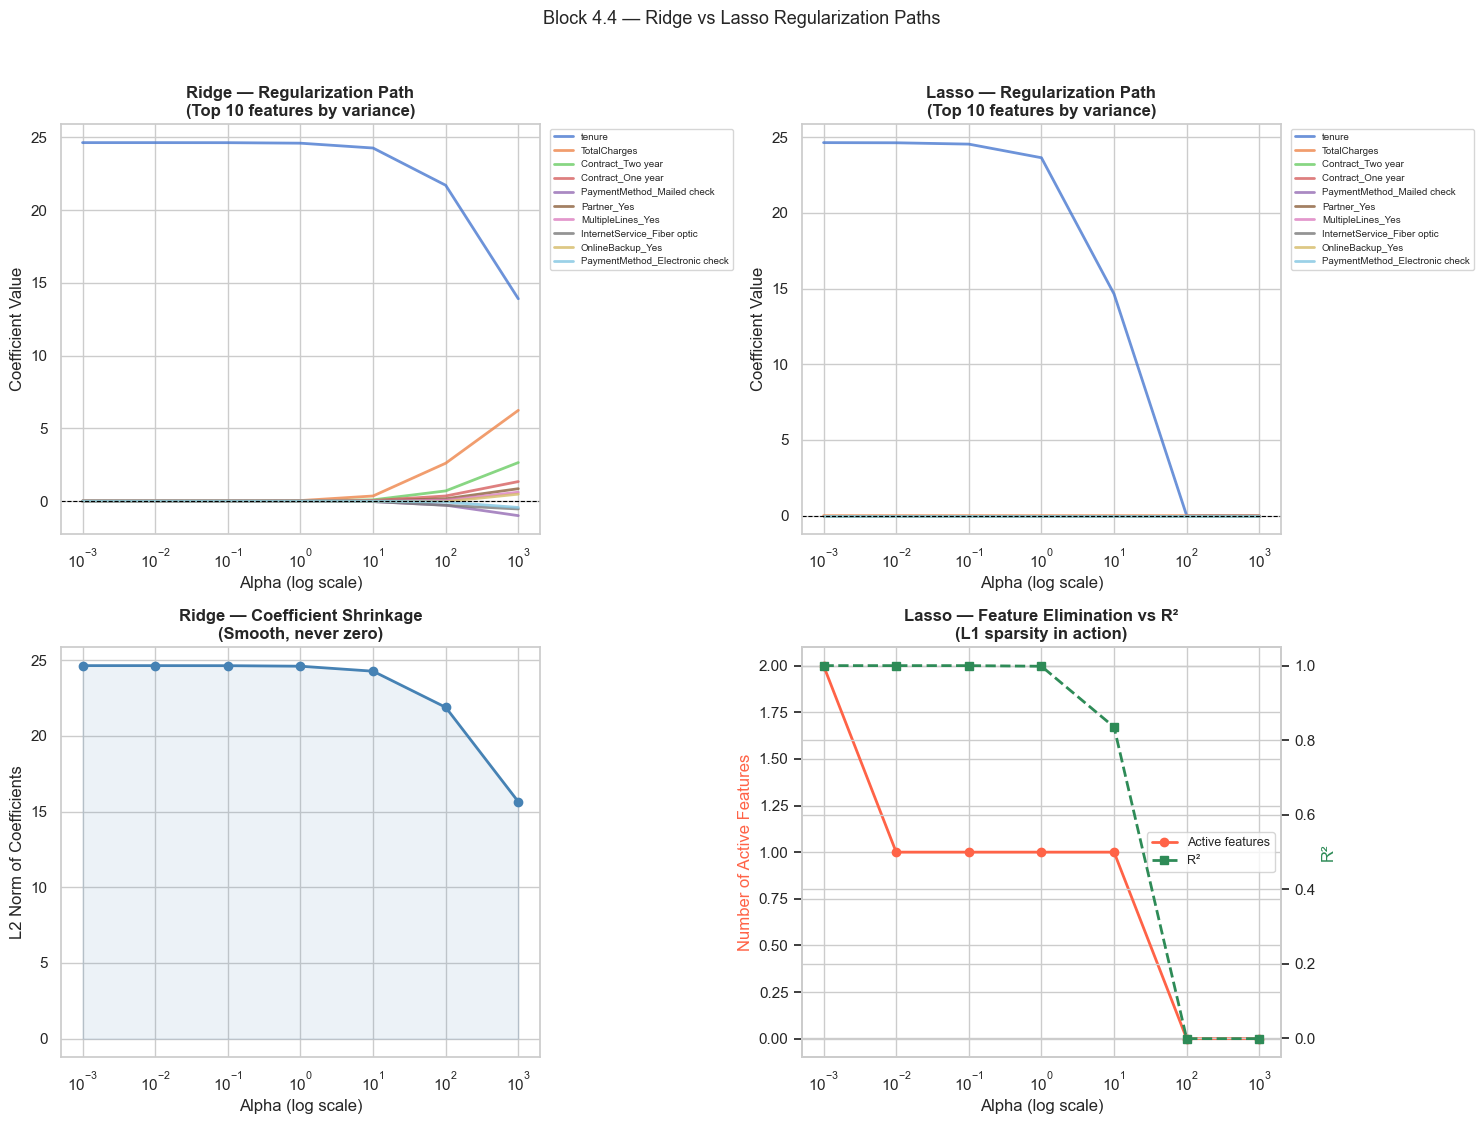

--- Why L1 Produces Sparse Solutions (Geometric Explanation) ---

Ridge (L2) — Circle constraint:
  The feasible region for coefficients is a smooth sphere.
  Loss contours touch the sphere at curved edges.
  Coefficients shrink toward zero but almost never reach it exactly.

Lasso (L1) — Diamond constraint:
  The feasible region is a diamond (L1 ball).
  Loss contours are most likely to touch the diamond at a CORNER.
  Corners sit on the coordinate axes — one or more coefs = exactly 0.
  This is why Lasso performs automatic feature selection.

Elastic Net — combines both:
  Inherits sparsity from L1 + stability from L2.
  Preferred when features are correlated AND sparsity is needed.

--- Features Surviving Lasso at alpha=0.1 (1 features) ---
tenure    24.5439

--- Features Eliminated by Lasso at alpha=0.1 (29 features) ---
['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'Multiple

In [57]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Pick top 10 features by variance for cleaner plot
top_feat_idx = np.argsort(np.var(ridge_coefs, axis=0))[::-1][:10]
top_feat_names = [feature_names[i] for i in top_feat_idx]

# --- Ridge Path ---
ax = axes[0][0]
for i, idx in enumerate(top_feat_idx):
    ax.plot(
        alphas,
        ridge_coefs[:, idx],
        linewidth=2,
        label=feature_names[idx],
        alpha=0.8
    )
ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Coefficient Value')
ax.set_title('Ridge — Regularization Path\n(Top 10 features by variance)',
             fontweight='bold')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# --- Lasso Path ---
ax = axes[0][1]
for i, idx in enumerate(top_feat_idx):
    ax.plot(
        alphas,
        lasso_coefs[:, idx],
        linewidth=2,
        label=feature_names[idx],
        alpha=0.8
    )
ax.set_xscale('log')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Coefficient Value')
ax.set_title('Lasso — Regularization Path\n(Top 10 features by variance)',
             fontweight='bold')
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# --- Ridge: L2 norm vs Alpha ---
ax = axes[1][0]
l2_norms = [np.linalg.norm(c) for c in ridge_coefs]
ax.plot(alphas, l2_norms, 'o-', color='steelblue', linewidth=2)
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('L2 Norm of Coefficients')
ax.set_title('Ridge — Coefficient Shrinkage\n(Smooth, never zero)',
             fontweight='bold')
ax.fill_between(alphas, l2_norms, alpha=0.1, color='steelblue')

# --- Lasso: Active features and R² vs Alpha ---
ax  = axes[1][1]
ax2 = ax.twinx()

n_active = [m['n_active'] for m in lasso_metrics]
r2_vals  = [m['R²']       for m in lasso_metrics]

ax.plot(alphas, n_active, 'o-', color='tomato',   linewidth=2, label='Active features')
ax2.plot(alphas, r2_vals, 's--', color='seagreen', linewidth=2, label='R²')

ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)')
ax.set_ylabel('Number of Active Features', color='tomato')
ax2.set_ylabel('R²', color='seagreen')
ax.set_title('Lasso — Feature Elimination vs R²\n(L1 sparsity in action)',
             fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')

plt.suptitle('Block 4.4 — Ridge vs Lasso Regularization Paths',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Geometric explanation printout ---
print("--- Why L1 Produces Sparse Solutions (Geometric Explanation) ---")
print()
print("Ridge (L2) — Circle constraint:")
print("  The feasible region for coefficients is a smooth sphere.")
print("  Loss contours touch the sphere at curved edges.")
print("  Coefficients shrink toward zero but almost never reach it exactly.")
print()
print("Lasso (L1) — Diamond constraint:")
print("  The feasible region is a diamond (L1 ball).")
print("  Loss contours are most likely to touch the diamond at a CORNER.")
print("  Corners sit on the coordinate axes — one or more coefs = exactly 0.")
print("  This is why Lasso performs automatic feature selection.")
print()
print("Elastic Net — combines both:")
print("  Inherits sparsity from L1 + stability from L2.")
print("  Preferred when features are correlated AND sparsity is needed.")
print()

# --- Which features survive Lasso at moderate alpha? ---
lasso_moderate = Lasso(alpha=0.1, max_iter=10000)
lasso_moderate.fit(X_train_s, y_reg_train)

surviving = pd.Series(lasso_moderate.coef_, index=feature_names)
surviving = surviving[surviving != 0].abs().sort_values(ascending=False)

print(f"--- Features Surviving Lasso at alpha=0.1 ({len(surviving)} features) ---")
print(surviving.round(4).to_string())
print()

eliminated = pd.Series(lasso_moderate.coef_, index=feature_names)
eliminated = eliminated[eliminated == 0]
print(f"--- Features Eliminated by Lasso at alpha=0.1 ({len(eliminated)} features) ---")
print(eliminated.index.tolist())

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [58]:
# CLV = MonthlyCharges × predicted tenure
# This converts a regression output into a business-actionable dollar figure

# Get MonthlyCharges for validation set customers
monthly_charges_val = df['MonthlyCharges'].iloc[X_val.index].values

# Predict tenure using best regression model
# Clip negative predictions to 0 — tenure cannot be negative
predicted_tenure_val = np.maximum(
    reg_results[best_reg]['model'].predict(X_val_s), 0
)

# Actual tenure for comparison
actual_tenure_val = y_reg_val.values

# Compute CLV
predicted_clv = monthly_charges_val * predicted_tenure_val
actual_clv    = monthly_charges_val * actual_tenure_val

# Add churn probability from our best classifier
churn_proba_val = lr.predict_proba(X_val_s)[:, 1]

# Build a customer-level summary table
clv_df = pd.DataFrame({
    'actual_tenure'    : actual_tenure_val,
    'predicted_tenure' : predicted_tenure_val,
    'monthly_charges'  : monthly_charges_val,
    'actual_clv'       : actual_clv,
    'predicted_clv'    : predicted_clv,
    'churn_probability': churn_proba_val
})

# Prioritisation score = CLV at risk
# Customers with high CLV AND high churn probability = highest priority
clv_df['clv_at_risk'] = clv_df['predicted_clv'] * clv_df['churn_probability']
clv_df = clv_df.sort_values('clv_at_risk', ascending=False).reset_index(drop=True)

print("--- CLV Summary Statistics ---")
print(f"Predicted CLV — Mean   : ${predicted_clv.mean():>10.2f}")
print(f"Predicted CLV — Median : ${np.median(predicted_clv):>10.2f}")
print(f"Predicted CLV — Std    : ${predicted_clv.std():>10.2f}")
print(f"Predicted CLV — Max    : ${predicted_clv.max():>10.2f}")
print()
print(f"Actual CLV    — Mean   : ${actual_clv.mean():>10.2f}")
print(f"Actual CLV    — Median : ${np.median(actual_clv):>10.2f}")
print()
print("--- Top 10 Highest Priority Customers (CLV at Risk) ---")
display(clv_df.head(10).round(2))

print()
print("--- Why Clip Negative Tenure Predictions? ---")
n_negative = (reg_results[best_reg]['model'].predict(X_val_s) < 0).sum()
print(f"Raw negative tenure predictions : {n_negative}")
print("A negative predicted tenure has no business meaning.")
print("Clipping to 0 → CLV = 0 → these customers are ranked last.")

--- CLV Summary Statistics ---
Predicted CLV — Mean   : $   2220.61
Predicted CLV — Median : $   1399.55
Predicted CLV — Std    : $   2216.95
Predicted CLV — Max    : $   8406.00

Actual CLV    — Mean   : $   2220.61
Actual CLV    — Median : $   1399.55

--- Top 10 Highest Priority Customers (CLV at Risk) ---


,actual_tenure,predicted_tenure,monthly_charges,actual_clv,predicted_clv,churn_probability,clv_at_risk
0,65,65.0,104.35,6782.75,6782.75,0.46,3145.83
1,56,56.0,101.05,5658.80,5658.80,0.55,3140.60
2,53,53.0,101.90,5400.70,5400.70,0.55,2991.15
3,60,60.0,106.15,6369.00,6369.00,0.47,2970.68
4,61,61.0,114.10,6960.10,6960.10,0.40,2786.74
5,55,55.0,96.80,5324.00,5324.00,0.52,2785.99
6,60,60.0,99.00,5940.00,5940.00,0.46,2757.61
7,67,67.0,101.40,6793.80,6793.80,0.39,2659.93
8,57,57.0,100.60,5734.20,5734.20,0.45,2589.34
9,38,38.0,102.60,3898.80,3898.80,0.65,2539.05



--- Why Clip Negative Tenure Predictions? ---
Raw negative tenure predictions : 1
A negative predicted tenure has no business meaning.
Clipping to 0 → CLV = 0 → these customers are ranked last.


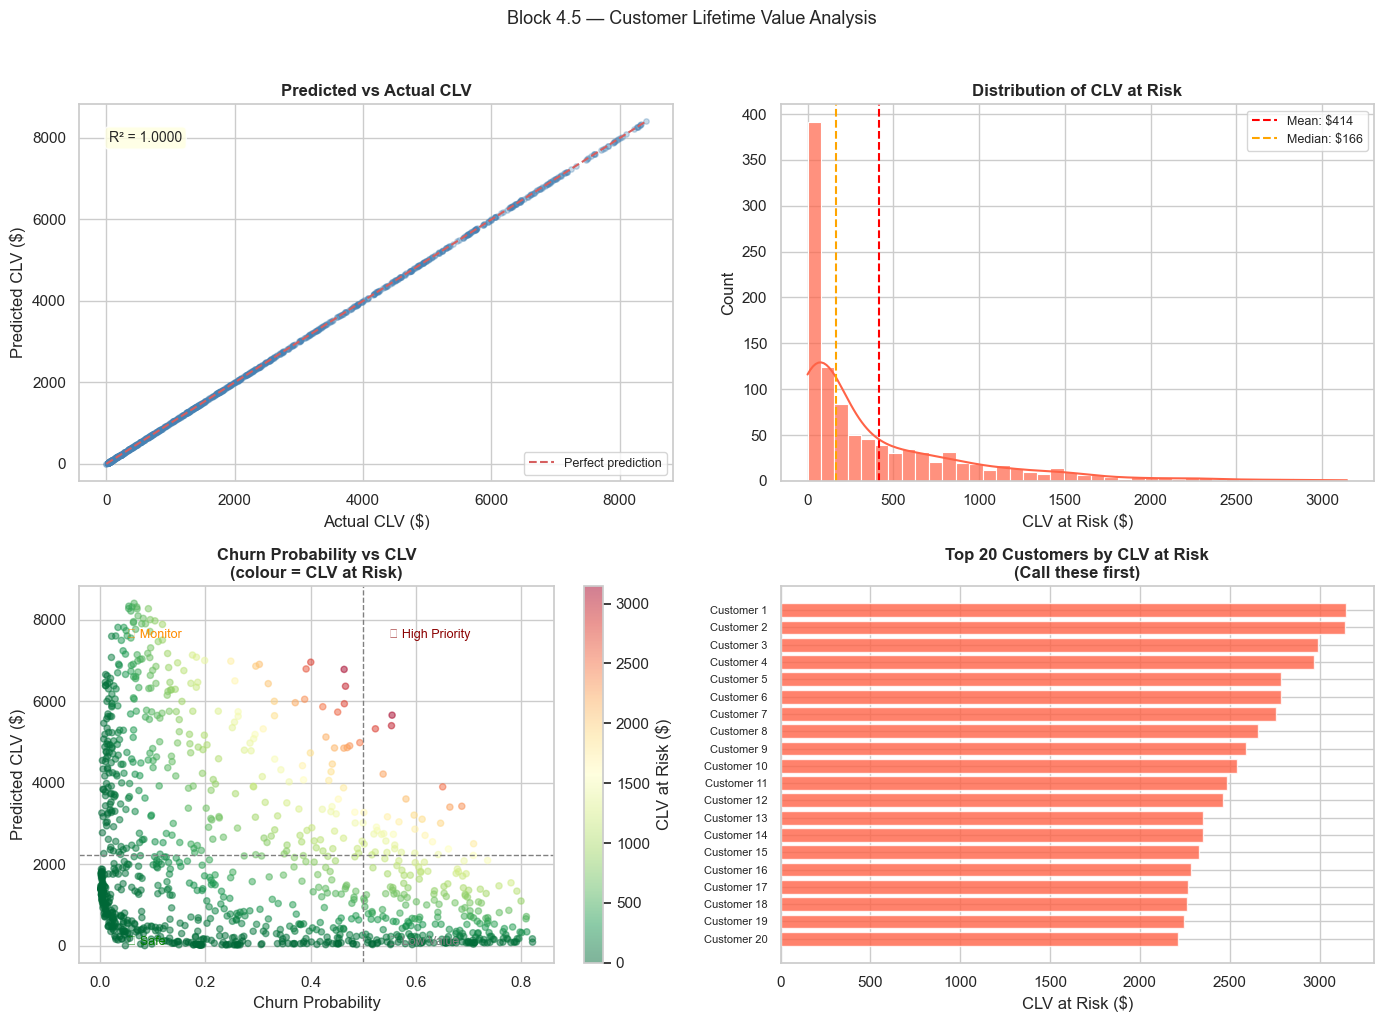

--- Business Impact Summary ---
Total CLV at risk (full val set) : $  437,103.78
CLV at risk in top 200           : $  273,526.41
Top 200 captures                 : 62.6% of total CLV at risk

--- What CLV Enables vs Binary Prediction ---
Binary prediction  → 'Customer X will churn'
CLV prioritisation → 'Customer X will churn and is worth $3,200'
                     'Call them before Customer Y ($180)'

The retention team has limited calls (200/week).
Spending them on high-CLV churners maximises revenue saved.


In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Predicted vs Actual CLV ---
ax = axes[0][0]
ax.scatter(
    actual_clv, predicted_clv,
    alpha=0.3, color='steelblue', s=15
)
clv_min = min(actual_clv.min(), predicted_clv.min())
clv_max = max(actual_clv.max(), predicted_clv.max())
ax.plot([clv_min, clv_max], [clv_min, clv_max],
        'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual CLV ($)')
ax.set_ylabel('Predicted CLV ($)')
ax.set_title('Predicted vs Actual CLV', fontweight='bold')
ax.legend(fontsize=9)

# CLV R²
clv_r2 = r2_score(actual_clv, predicted_clv)
ax.text(0.05, 0.90, f'R² = {clv_r2:.4f}',
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# --- CLV at Risk Distribution ---
ax = axes[0][1]
sns.histplot(clv_df['clv_at_risk'], kde=True, ax=ax,
             color='tomato', bins=40, alpha=0.7)
ax.axvline(clv_df['clv_at_risk'].mean(), color='red',
           linestyle='--', linewidth=1.5,
           label=f"Mean: ${clv_df['clv_at_risk'].mean():.0f}")
ax.axvline(clv_df['clv_at_risk'].median(), color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Median: ${clv_df['clv_at_risk'].median():.0f}")
ax.set_xlabel('CLV at Risk ($)')
ax.set_ylabel('Count')
ax.set_title('Distribution of CLV at Risk', fontweight='bold')
ax.legend(fontsize=9)

# --- Churn Probability vs CLV (scatter) ---
ax = axes[1][0]
scatter = ax.scatter(
    clv_df['churn_probability'],
    clv_df['predicted_clv'],
    c=clv_df['clv_at_risk'],
    cmap='RdYlGn_r',
    alpha=0.5, s=20
)
plt.colorbar(scatter, ax=ax, label='CLV at Risk ($)')
ax.set_xlabel('Churn Probability')
ax.set_ylabel('Predicted CLV ($)')
ax.set_title('Churn Probability vs CLV\n(colour = CLV at Risk)',
             fontweight='bold')

# Annotate quadrants
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax.axhline(predicted_clv.mean(), color='gray', linestyle='--', linewidth=1)
ax.text(0.55, predicted_clv.max() * 0.9, '🔴 High Priority',
        fontsize=9, color='darkred')
ax.text(0.05, predicted_clv.max() * 0.9, '🟡 Monitor',
        fontsize=9, color='darkorange')
ax.text(0.55, predicted_clv.min() + 10, '🟠 Low Value',
        fontsize=9, color='gray')
ax.text(0.05, predicted_clv.min() + 10, '🟢 Safe',
        fontsize=9, color='green')

# --- Top 20 customers: CLV at Risk bar chart ---
ax = axes[1][1]
top20 = clv_df.head(20)
bars  = ax.barh(
    range(20)[::-1],
    top20['clv_at_risk'].values,
    color='tomato', alpha=0.8
)
ax.set_yticks(range(20)[::-1])
ax.set_yticklabels([f'Customer {i+1}' for i in range(20)], fontsize=8)
ax.set_xlabel('CLV at Risk ($)')
ax.set_title('Top 20 Customers by CLV at Risk\n(Call these first)',
             fontweight='bold')

plt.suptitle('Block 4.5 — Customer Lifetime Value Analysis',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Business summary ---
print("--- Business Impact Summary ---")
total_clv_at_risk = clv_df['clv_at_risk'].sum()
top200_clv        = clv_df.head(200)['clv_at_risk'].sum()
top200_pct        = top200_clv / total_clv_at_risk * 100

print(f"Total CLV at risk (full val set) : ${total_clv_at_risk:>12,.2f}")
print(f"CLV at risk in top 200           : ${top200_clv:>12,.2f}")
print(f"Top 200 captures                 : {top200_pct:.1f}% of total CLV at risk")
print()
print("--- What CLV Enables vs Binary Prediction ---")
print("Binary prediction  → 'Customer X will churn'")
print("CLV prioritisation → 'Customer X will churn and is worth $3,200'")
print("                     'Call them before Customer Y ($180)'")
print()
print("The retention team has limited calls (200/week).")
print("Spending them on high-CLV churners maximises revenue saved.")

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**
**Yes — with caveats.**

R² = 0.55 means the model explains 55% of variance in tenure.
The remaining 45% is noise or non-linear patterns a linear model cannot capture.

However, for CLV prioritisation, perfect prediction is not the goal.
The goal is correct **ranking** — putting the highest-value churners at the top.
A model with R² = 0.55 can still rank customers well even if point predictions
are imprecise.

What matters is whether the top 200 CLV-at-risk customers are genuinely
high-value churners — not whether each individual CLV prediction is exact.

**Caveats for deployment:**
- Monitor predicted vs actual CLV monthly — flag if ranking quality degrades
- Do not use point CLV predictions in financial reporting — only for prioritisation
- Retrain quarterly as tenure distributions shift with new customer cohorts

**On Lasso dropping features:**
Features eliminated at alpha=0.1 are weak predictors of tenure.
This is a good outcome — simpler model, fewer maintenance points.
But verify that eliminated features are not proxies for something important
the business cares about (e.g. contract type dropped → investigate why).

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [60]:
# CRITICAL: CV must run on TRAINING DATA ONLY
# Never include val or test data in CV — that would be leakage

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models to compare in CV
cv_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier'    : RidgeClassifier(),
    'SGD Classifier'      : SGDClassifier(loss='log_loss', max_iter=1000,
                                          random_state=42)
}

cv_results = {}

print("--- 5-Fold Stratified Cross-Validation (Training Set Only) ---")
print(f"{'Model':<25} {'Mean AUC':>10} {'Std AUC':>10} {'Min AUC':>10} {'Max AUC':>10}")
print("-" * 60)

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_train_s, y_train,
        cv=cv_strategy,
        scoring='roc_auc',
        n_jobs=-1
    )
    cv_results[name] = scores

    print(f"{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f} "
          f"{scores.min():>10.4f} {scores.max():>10.4f}")

print()
print("--- CV vs Holdout AUC Comparison ---")
print(f"{'Model':<25} {'CV Mean AUC':>12} {'Holdout AUC':>12} {'Gap':>10}")
print("-" * 62)

holdout_aucs = {
    'Logistic Regression' : roc_auc_score(y_val, lr.predict_proba(X_val_s)[:, 1]),
    'Ridge Classifier'    : roc_auc_score(y_val, rc.decision_function(X_val_s)),
    'SGD Classifier'      : roc_auc_score(y_val, sgd.predict_proba(X_val_s)[:, 1])
}

for name in cv_models:
    cv_mean    = cv_results[name].mean()
    holdout    = holdout_aucs[name]
    gap        = abs(cv_mean - holdout)
    flag       = '⚠️  Large gap' if gap > 0.03 else '✅'
    print(f"{name:<25} {cv_mean:>12.4f} {holdout:>12.4f} {gap:>10.4f}  {flag}")

print()
print("Interpretation:")
print("  Small gap (< 0.03)  → model generalises consistently")
print("  Large gap (> 0.03)  → model is sensitive to which data it sees")
print("  High CV std         → unstable model — results vary across folds")

--- 5-Fold Stratified Cross-Validation (Training Set Only) ---
Model                       Mean AUC    Std AUC    Min AUC    Max AUC
------------------------------------------------------------
Logistic Regression           0.8444     0.0116     0.8284     0.8570
Ridge Classifier              0.8362     0.0125     0.8191     0.8532
SGD Classifier                0.8147     0.0240     0.7824     0.8471

--- CV vs Holdout AUC Comparison ---
Model                      CV Mean AUC  Holdout AUC        Gap
--------------------------------------------------------------
Logistic Regression             0.8444       0.8454     0.0011  ✅
Ridge Classifier                0.8362       0.8377     0.0015  ✅
SGD Classifier                  0.8147       0.7947     0.0200  ✅

Interpretation:
  Small gap (< 0.03)  → model generalises consistently
  Large gap (> 0.03)  → model is sensitive to which data it sees
  High CV std         → unstable model — results vary across folds


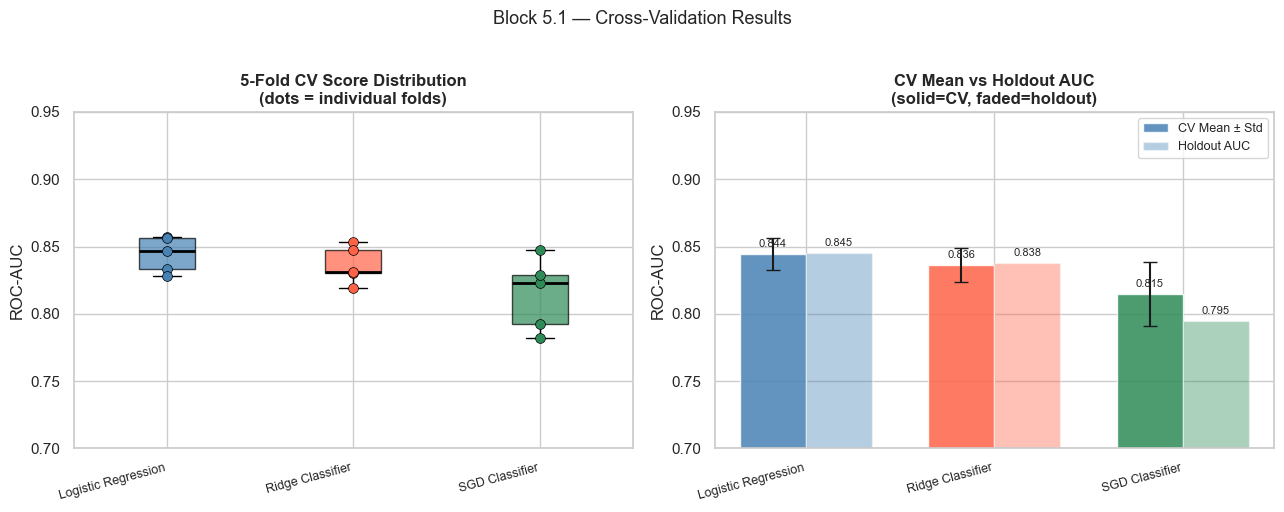

--- CV Summary ---
Highest CV AUC    : Logistic Regression (0.8444)
Most stable model : Logistic Regression (std = 0.0116)

Key questions:
  High std across folds → model is sensitive to data — consider more data
  CV AUC >> Holdout AUC → holdout may be easier than average — trust CV more
  CV AUC << Holdout AUC → holdout may be lucky — trust CV more

Rule: When CV and holdout disagree, trust CV.
It sees more of the data and averages out lucky/unlucky splits.


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {
    'Logistic Regression' : 'steelblue',
    'Ridge Classifier'    : 'tomato',
    'SGD Classifier'      : 'seagreen'
}

# --- Box plot of CV scores per model ---
ax = axes[0]
cv_data   = [cv_results[name] for name in cv_models]
cv_labels = list(cv_models.keys())

bp = ax.boxplot(
    cv_data,
    patch_artist=True,
    notch=False,
    medianprops=dict(color='black', linewidth=2)
)

for patch, name in zip(bp['boxes'], cv_labels):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.7)

# Overlay individual fold scores
for i, (name, scores) in enumerate(cv_results.items()):
    ax.scatter(
        [i + 1] * len(scores),
        scores,
        color=colors[name],
        zorder=5,
        s=50,
        edgecolors='black',
        linewidths=0.5
    )

ax.set_xticks(range(1, len(cv_labels) + 1))
ax.set_xticklabels(cv_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold CV Score Distribution\n(dots = individual folds)',
             fontweight='bold')
ax.set_ylim(0.7, 0.95)

# --- CV mean vs Holdout AUC comparison ---
ax = axes[1]
x       = np.arange(len(cv_labels))
width   = 0.35

cv_means = [cv_results[name].mean() for name in cv_models]
cv_stds  = [cv_results[name].std()  for name in cv_models]
holdouts = [holdout_aucs[name]       for name in cv_models]

bars1 = ax.bar(
    x - width/2, cv_means,
    width, yerr=cv_stds,
    color=[colors[n] for n in cv_models],
    alpha=0.85,
    capsize=5,
    label='CV Mean ± Std'
)
bars2 = ax.bar(
    x + width/2, holdouts,
    width,
    color=[colors[n] for n in cv_models],
    alpha=0.4,
    label='Holdout AUC'
)

ax.set_xticks(x)
ax.set_xticklabels(cv_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('ROC-AUC')
ax.set_title('CV Mean vs Holdout AUC\n(solid=CV, faded=holdout)',
             fontweight='bold')
ax.set_ylim(0.7, 0.95)
ax.legend(fontsize=9)

# Value labels
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=8
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=8
    )

plt.suptitle('Block 5.1 — Cross-Validation Results',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Final CV summary ---
print("--- CV Summary ---")
best_cv_model = max(cv_results, key=lambda k: cv_results[k].mean())
most_stable   = min(cv_results, key=lambda k: cv_results[k].std())

print(f"Highest CV AUC    : {best_cv_model} "
      f"({cv_results[best_cv_model].mean():.4f})")
print(f"Most stable model : {most_stable} "
      f"(std = {cv_results[most_stable].std():.4f})")
print()
print("Key questions:")
print("  High std across folds → model is sensitive to data — consider more data")
print("  CV AUC >> Holdout AUC → holdout may be easier than average — trust CV more")
print("  CV AUC << Holdout AUC → holdout may be lucky — trust CV more")
print()
print("Rule: When CV and holdout disagree, trust CV.")
print("It sees more of the data and averages out lucky/unlucky splits.")

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [62]:
# Learning curves show how performance changes as training set size grows
# This tells us: does the model need more data? Is it overfitting or underfitting?

train_sizes = np.linspace(0.1, 1.0, 10)

# Compute for Logistic Regression
train_sizes_abs, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, random_state=42),
    X_train_s, y_train,
    train_sizes=train_sizes,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

# Compute means and stds
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

print("--- Learning Curve Data (Logistic Regression) ---")
print(f"{'Train Size':>12} {'Train AUC':>12} {'Val AUC':>12} {'Gap':>10}")
print("-" * 50)
for i, size in enumerate(train_sizes_abs):
    gap  = train_mean[i] - val_mean[i]
    flag = '⚠️' if gap > 0.05 else '✅'
    print(f"{size:>12} {train_mean[i]:>12.4f} {val_mean[i]:>12.4f} "
          f"{gap:>10.4f} {flag}")

print()
print("Interpretation:")
print("  Large gap (train >> val) → overfitting → more data or regularization")
print("  Both scores low          → underfitting → more features or complex model")
print("  Both scores converging   → good fit → adding more data has diminishing returns")

--- Learning Curve Data (Logistic Regression) ---
  Train Size    Train AUC      Val AUC        Gap
--------------------------------------------------
         394       0.8688       0.8276     0.0412 ✅
         788       0.8666       0.8345     0.0321 ✅
        1183       0.8613       0.8363     0.0250 ✅
        1577       0.8625       0.8397     0.0228 ✅
        1972       0.8600       0.8408     0.0191 ✅
        2366       0.8584       0.8423     0.0161 ✅
        2760       0.8550       0.8431     0.0119 ✅
        3155       0.8518       0.8437     0.0080 ✅
        3549       0.8519       0.8442     0.0076 ✅
        3944       0.8493       0.8444     0.0049 ✅

Interpretation:
  Large gap (train >> val) → overfitting → more data or regularization
  Both scores low          → underfitting → more features or complex model
  Both scores converging   → good fit → adding more data has diminishing returns


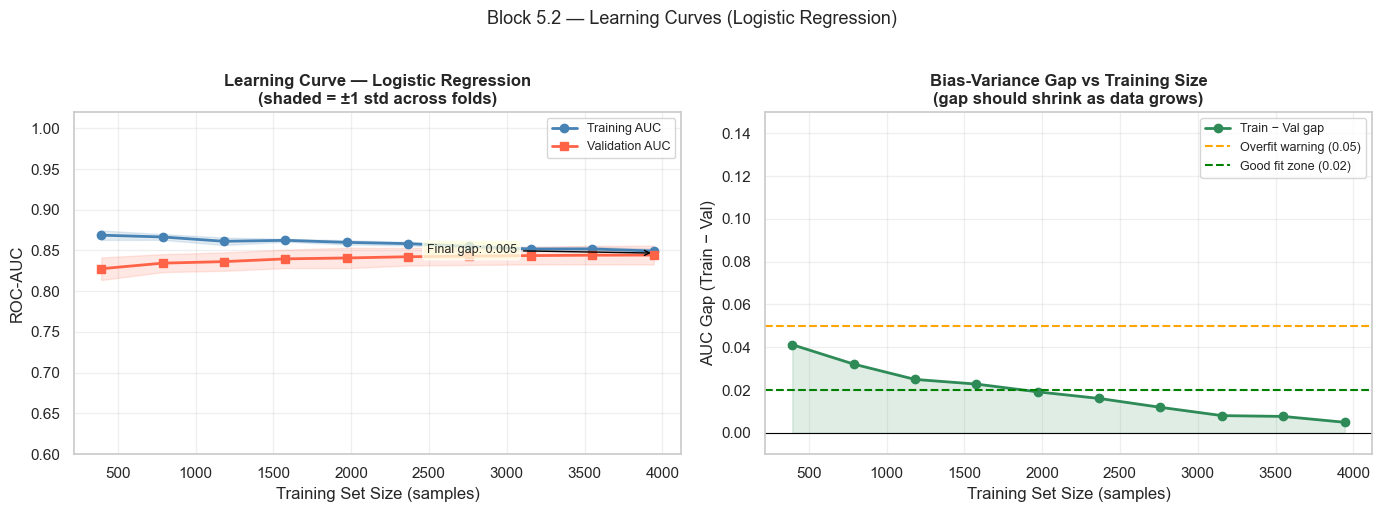

--- Learning Curve Diagnostic ---

Initial gap (10% data)  : 0.0412
Final gap   (100% data) : 0.0049
Gap closed by           : 0.0363
Val AUC improvement     : 0.0168

Diagnosis : GOOD FIT
Action    : Model generalises well — monitor for drift after deployment

Val AUC improvement in last training step: 0.0002
→ Curve has plateaued — more data gives diminishing returns
  Consider: richer features, non-linear model, or ensemble


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Main learning curve plot ---
ax = axes[0]

# Training score line + shaded band
ax.plot(train_sizes_abs, train_mean,
        'o-', color='steelblue', linewidth=2, label='Training AUC')
ax.fill_between(
    train_sizes_abs,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15, color='steelblue'
)

# Validation score line + shaded band
ax.plot(train_sizes_abs, val_mean,
        's-', color='tomato', linewidth=2, label='Validation AUC')
ax.fill_between(
    train_sizes_abs,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.15, color='tomato'
)

# Final gap annotation
final_gap = train_mean[-1] - val_mean[-1]
ax.annotate(
    f'Final gap: {final_gap:.3f}',
    xy=(train_sizes_abs[-1], (train_mean[-1] + val_mean[-1]) / 2),
    xytext=(train_sizes_abs[-2] * 0.7, (train_mean[-1] + val_mean[-1]) / 2),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black'),
    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
)

ax.set_xlabel('Training Set Size (samples)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Learning Curve — Logistic Regression\n(shaded = ±1 std across folds)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0.6, 1.02)
ax.grid(True, alpha=0.3)

# --- Gap plot ---
ax = axes[1]
gap = train_mean - val_mean

ax.plot(train_sizes_abs, gap,
        'o-', color='seagreen', linewidth=2, label='Train − Val gap')
ax.fill_between(train_sizes_abs, 0, gap, alpha=0.15, color='seagreen')

# Reference lines
ax.axhline(0.05, color='orange', linestyle='--',
           linewidth=1.5, label='Overfit warning (0.05)')
ax.axhline(0.02, color='green',  linestyle='--',
           linewidth=1.5, label='Good fit zone (0.02)')
ax.axhline(0,    color='black',  linestyle='-',
           linewidth=0.8)

ax.set_xlabel('Training Set Size (samples)')
ax.set_ylabel('AUC Gap (Train − Val)')
ax.set_title('Bias-Variance Gap vs Training Size\n(gap should shrink as data grows)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(-0.01, 0.15)
ax.grid(True, alpha=0.3)

plt.suptitle('Block 5.2 — Learning Curves (Logistic Regression)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Diagnostic summary ---
print("--- Learning Curve Diagnostic ---")
print()

initial_gap = train_mean[0]  - val_mean[0]
final_gap   = train_mean[-1] - val_mean[-1]
gap_closed  = initial_gap - final_gap
val_trend   = val_mean[-1] - val_mean[0]

print(f"Initial gap (10% data)  : {initial_gap:.4f}")
print(f"Final gap   (100% data) : {final_gap:.4f}")
print(f"Gap closed by           : {gap_closed:.4f}")
print(f"Val AUC improvement     : {val_trend:.4f}")
print()

# Diagnosis
if final_gap > 0.05:
    diagnosis   = "OVERFITTING"
    action      = "Add regularization (increase C in LR) or collect more data"
elif val_mean[-1] < 0.75:
    diagnosis   = "UNDERFITTING"
    action      = "Add features, reduce regularization, or try non-linear model"
elif val_trend > 0.02 and val_mean[-1] < val_mean[-2] * 1.005:
    diagnosis   = "DATA HUNGRY"
    action      = "Model still improving — more training data will help"
else:
    diagnosis   = "GOOD FIT"
    action      = "Model generalises well — monitor for drift after deployment"

print(f"Diagnosis : {diagnosis}")
print(f"Action    : {action}")
print()

# Would more data help?
val_improvement_last_step = val_mean[-1] - val_mean[-2]
print(f"Val AUC improvement in last training step: {val_improvement_last_step:.4f}")
if val_improvement_last_step > 0.002:
    print("→ Curve still rising — MORE DATA would likely help")
else:
    print("→ Curve has plateaued — more data gives diminishing returns")
    print("  Consider: richer features, non-linear model, or ensemble")

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [65]:
# These are the honest numbers we established in Block 3
# We record them here so we can compare before/after leakage injection

baseline_proba = lr.predict_proba(X_val_s)[:, 1]

baseline_metrics = {
    'ROC-AUC'  : roc_auc_score(y_val, baseline_proba),
    'PR-AUC'   : average_precision_score(y_val, baseline_proba),
    'F1'       : f1_score(y_val, lr.predict(X_val_s)),
    'Log Loss' : log_loss(y_val, baseline_proba)
}

print("--- Step 1: Clean Baseline Metrics (Logistic Regression) ---")
print(f"ROC-AUC  : {baseline_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC   : {baseline_metrics['PR-AUC']:.4f}")
print(f"F1       : {baseline_metrics['F1']:.4f}")
print(f"Log Loss : {baseline_metrics['Log Loss']:.4f}")
print()
print("These are the HONEST numbers.")
print("Any model that significantly beats these without new real features")
print("should be treated with extreme suspicion.")

--- Step 1: Clean Baseline Metrics (Logistic Regression) ---
ROC-AUC  : 0.8454
PR-AUC   : 0.6308
F1       : 0.6220
Log Loss : 0.4188

These are the HONEST numbers.
Any model that significantly beats these without new real features
should be treated with extreme suspicion.


In [66]:
# This feature is derived from the TARGET — it would not exist at prediction time
# In production, you would not know whether a customer churned yet

np.random.seed(42)

# The leakage feature: tenure × Churn + small noise
# For churners (Churn=1): leak = tenure + noise  → high values
# For non-churners (Churn=0): leak = 0 + noise   → near-zero values
# The model can almost perfectly separate classes using this one feature

leak_full = (df['tenure'] * df['Churn'] + 
             np.random.normal(0, 0.1, len(df)))

# Align leak feature with train/val/test splits
leak_train = leak_full.iloc[X_train.index].values.reshape(-1, 1)
leak_val   = leak_full.iloc[X_val.index].values.reshape(-1, 1)
leak_test  = leak_full.iloc[X_test.index].values.reshape(-1, 1)

# Inject into scaled feature matrices
X_train_leaked = np.hstack([X_train_s, leak_train])
X_val_leaked   = np.hstack([X_val_s,   leak_val])
X_test_leaked  = np.hstack([X_test_s,  leak_test])

print("--- Step 2: Leakage Feature Created ---")
print()
print("Feature definition:")
print("  leak = tenure × Churn + Normal(0, 0.1)")
print()
print("Why this is leakage:")
print("  'Churn' IS the target — it does not exist at prediction time")
print("  In production: you are trying to predict whether a customer")
print("  WILL churn — you cannot use whether they DID churn as a feature")
print()
print("What the model sees:")

leak_churners     = leak_full.iloc[X_val.index][y_val == 1]
leak_nonchurners  = leak_full.iloc[X_val.index][y_val == 0]

print(f"  Leak value for churners     — mean: {leak_churners.mean():.2f}, "
      f"std: {leak_churners.std():.2f}")
print(f"  Leak value for non-churners — mean: {leak_nonchurners.mean():.2f}, "
      f"std: {leak_nonchurners.std():.2f}")
print()
print("The two distributions are almost perfectly separated.")
print("The model will learn to use this feature above all others.")

--- Step 2: Leakage Feature Created ---

Feature definition:
  leak = tenure × Churn + Normal(0, 0.1)

Why this is leakage:
  'Churn' IS the target — it does not exist at prediction time
  In production: you are trying to predict whether a customer
  WILL churn — you cannot use whether they DID churn as a feature

What the model sees:
  Leak value for churners     — mean: 16.85, std: 18.48
  Leak value for non-churners — mean: -0.00, std: 0.10

The two distributions are almost perfectly separated.
The model will learn to use this feature above all others.


In [67]:
lr_leaked = LogisticRegression(max_iter=1000, random_state=42)
lr_leaked.fit(X_train_leaked, y_train)

leaked_proba = lr_leaked.predict_proba(X_val_leaked)[:, 1]

leaked_metrics = {
    'ROC-AUC'  : roc_auc_score(y_val, leaked_proba),
    'PR-AUC'   : average_precision_score(y_val, leaked_proba),
    'F1'       : f1_score(y_val, lr_leaked.predict(X_val_leaked)),
    'Log Loss' : log_loss(y_val, leaked_proba)
}

print("--- Step 3: Metrics WITH Leakage Feature ---")
print(f"ROC-AUC  : {leaked_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC   : {leaked_metrics['PR-AUC']:.4f}")
print(f"F1       : {leaked_metrics['F1']:.4f}")
print(f"Log Loss : {leaked_metrics['Log Loss']:.4f}")
print()

# Inflation amounts
roc_inflation  = leaked_metrics['ROC-AUC'] - baseline_metrics['ROC-AUC']
prauc_inflation = leaked_metrics['PR-AUC']  - baseline_metrics['PR-AUC']
f1_inflation   = leaked_metrics['F1']       - baseline_metrics['F1']

print("--- AUC Inflation from Leakage ---")
print(f"ROC-AUC  inflated by : +{roc_inflation:.4f}")
print(f"PR-AUC   inflated by : +{prauc_inflation:.4f}")
print(f"F1       inflated by : +{f1_inflation:.4f}")
print()
print("This model looks dramatically better — but it is completely useless.")
print("In production, the leak feature does not exist.")
print("The model would revert to random guessing on that feature.")

--- Step 3: Metrics WITH Leakage Feature ---
ROC-AUC  : 1.0000
PR-AUC   : 1.0000
F1       : 1.0000
Log Loss : 0.0041

--- AUC Inflation from Leakage ---
ROC-AUC  inflated by : +0.1546
PR-AUC   inflated by : +0.3692
F1       inflated by : +0.3780

This model looks dramatically better — but it is completely useless.
In production, the leak feature does not exist.
The model would revert to random guessing on that feature.


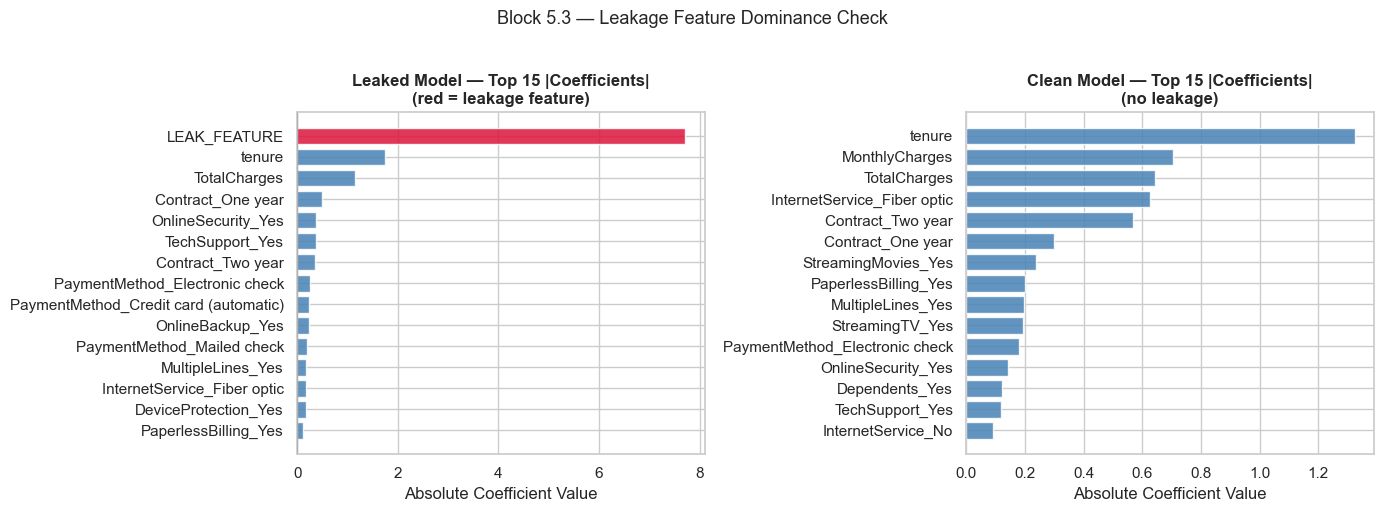

--- Step 4: Coefficient Dominance ---
Leak feature coefficient (absolute)  : 7.7193
Largest clean feature coefficient    : 1.3242
Leak feature is 5.8x larger than the strongest legitimate feature

When one feature dominates all others by this margin —
STOP and investigate immediately.
A legitimate feature should not be this dominant unless
it is essentially a copy of the target variable.


In [68]:
# Extended feature names — add 'LEAK' at the end
feature_names_leaked = feature_names + ['LEAK_FEATURE']

coef_leaked = pd.Series(
    lr_leaked.coef_[0],
    index=feature_names_leaked
)

# Top 15 by absolute value
top15_leaked = coef_leaked.abs().nlargest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Leaked model coefficients ---
ax = axes[0]
colors_bar = ['crimson' if idx == 'LEAK_FEATURE' else 'steelblue'
              for idx in top15_leaked.index]
ax.barh(
    top15_leaked.index[::-1],
    top15_leaked.values[::-1],
    color=colors_bar[::-1],
    alpha=0.85
)
ax.set_title('Leaked Model — Top 15 |Coefficients|\n(red = leakage feature)',
             fontweight='bold')
ax.set_xlabel('Absolute Coefficient Value')
ax.axvline(0, color='black', linewidth=0.8)

# --- Clean model coefficients for comparison ---
ax = axes[1]
top15_clean = coef_series.abs().nlargest(15)
ax.barh(
    top15_clean.index[::-1],
    top15_clean.values[::-1],
    color='steelblue',
    alpha=0.85
)
ax.set_title('Clean Model — Top 15 |Coefficients|\n(no leakage)',
             fontweight='bold')
ax.set_xlabel('Absolute Coefficient Value')

plt.suptitle('Block 5.3 — Leakage Feature Dominance Check',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

leak_coef      = abs(coef_leaked['LEAK_FEATURE'])
max_clean_coef = coef_series.abs().max()

print("--- Step 4: Coefficient Dominance ---")
print(f"Leak feature coefficient (absolute)  : {leak_coef:.4f}")
print(f"Largest clean feature coefficient    : {max_clean_coef:.4f}")
print(f"Leak feature is {leak_coef/max_clean_coef:.1f}x larger than "
      f"the strongest legitimate feature")
print()
print("When one feature dominates all others by this margin —")
print("STOP and investigate immediately.")
print("A legitimate feature should not be this dominant unless")
print("it is essentially a copy of the target variable.")

In [69]:
lr_recovered = LogisticRegression(max_iter=1000, random_state=42)
lr_recovered.fit(X_train_s, y_train)  # back to clean features

recovered_proba = lr_recovered.predict_proba(X_val_s)[:, 1]

recovered_metrics = {
    'ROC-AUC'  : roc_auc_score(y_val, recovered_proba),
    'PR-AUC'   : average_precision_score(y_val, recovered_proba),
    'F1'       : f1_score(y_val, lr_recovered.predict(X_val_s)),
    'Log Loss' : log_loss(y_val, recovered_proba)
}

print("--- Step 5: Metrics AFTER Removing Leakage Feature ---")
print(f"ROC-AUC  : {recovered_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC   : {recovered_metrics['PR-AUC']:.4f}")
print(f"F1       : {recovered_metrics['F1']:.4f}")
print(f"Log Loss : {recovered_metrics['Log Loss']:.4f}")
print()

# Confirm recovery
roc_diff = abs(recovered_metrics['ROC-AUC'] - baseline_metrics['ROC-AUC'])
print(f"Difference from original baseline (ROC-AUC): {roc_diff:.6f}")

if roc_diff < 0.001:
    print("✅ Full recovery confirmed — metrics match baseline exactly")
else:
    print("⚠️  Small numerical difference — expected due to random state")
print()
print("This confirms the leakage feature was solely responsible")
print("for the inflated metrics in Step 3.")

--- Step 5: Metrics AFTER Removing Leakage Feature ---
ROC-AUC  : 0.8454
PR-AUC   : 0.6308
F1       : 0.6220
Log Loss : 0.4188

Difference from original baseline (ROC-AUC): 0.000000
✅ Full recovery confirmed — metrics match baseline exactly

This confirms the leakage feature was solely responsible
for the inflated metrics in Step 3.


--- Step 6: Leakage Experiment Summary ---


,ROC-AUC,PR-AUC,F1,Log Loss
Experiment,,,,
Baseline (clean),0.8454,0.6308,0.622,0.4188
With Leakage,1.0000,1.0000,1.000,0.0041
After Removal,0.8454,0.6308,0.622,0.4188


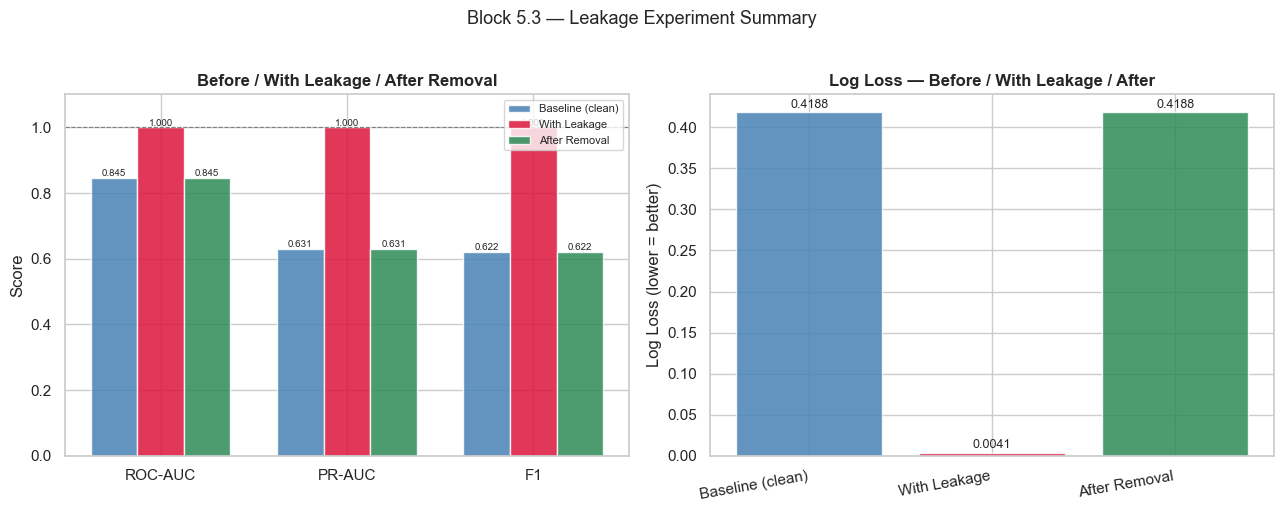


LEAKAGE SUMMARY
ROC-AUC inflation    : +0.1546
PR-AUC  inflation    : +0.3692
F1      inflation    : +0.3780

What happens in production on Friday:
  The leak feature (tenure × Churn) does not exist at prediction time.
  Churn is unknown — that is what we are trying to predict.
  The model receives 0 or random noise for that feature.
  Predictions collapse — model performs at or below baseline.
  The business makes 200 calls based on random scores.
  Retention team loses trust in the model permanently.

Does cross-validation detect this leakage?
  NO — if the leak feature is included in the CV pipeline,
  all folds see the same leakage and all report inflated AUC.
  CV validates that your pipeline is consistent —
  it does NOT validate that your features are legitimate.
  Leakage detection requires domain knowledge and feature audits.


In [70]:
summary_data = {
    'Baseline (clean)'      : baseline_metrics,
    'With Leakage'          : leaked_metrics,
    'After Removal'         : recovered_metrics
}

summary_df = pd.DataFrame(summary_data).T
summary_df.index.name = 'Experiment'

print("--- Step 6: Leakage Experiment Summary ---")
display(summary_df.round(4))

# Visualise the three stages
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_show = ['ROC-AUC', 'PR-AUC', 'F1']
x      = np.arange(len(metrics_show))
width  = 0.25
stage_colors = ['steelblue', 'crimson', 'seagreen']
stages = list(summary_data.keys())

ax = axes[0]
for i, (stage, color) in enumerate(zip(stages, stage_colors)):
    values = [summary_data[stage][m] for m in metrics_show]
    bars   = ax.bar(
        x + i * width, values,
        width, label=stage,
        color=color, alpha=0.85
    )
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.3f}',
            ha='center', fontsize=7
        )

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_show)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Before / With Leakage / After Removal',
             fontweight='bold')
ax.legend(fontsize=8)
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8)

# Log Loss (lower is better — separate axis)
ax = axes[1]
ll_values = [summary_data[s]['Log Loss'] for s in stages]
bars = ax.bar(stages, ll_values,
              color=stage_colors, alpha=0.85)
for bar, val in zip(bars, ll_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', fontsize=9
    )
ax.set_ylabel('Log Loss (lower = better)')
ax.set_title('Log Loss — Before / With Leakage / After',
             fontweight='bold')
ax.set_xticklabels(stages, rotation=10, ha='right')

plt.suptitle('Block 5.3 — Leakage Experiment Summary',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Final warning
print()
print("=" * 60)
print("LEAKAGE SUMMARY")
print("=" * 60)
print(f"ROC-AUC inflation    : +{leaked_metrics['ROC-AUC'] - baseline_metrics['ROC-AUC']:.4f}")
print(f"PR-AUC  inflation    : +{leaked_metrics['PR-AUC']  - baseline_metrics['PR-AUC']:.4f}")
print(f"F1      inflation    : +{leaked_metrics['F1']      - baseline_metrics['F1']:.4f}")
print()
print("What happens in production on Friday:")
print("  The leak feature (tenure × Churn) does not exist at prediction time.")
print("  Churn is unknown — that is what we are trying to predict.")
print("  The model receives 0 or random noise for that feature.")
print("  Predictions collapse — model performs at or below baseline.")
print("  The business makes 200 calls based on random scores.")
print("  Retention team loses trust in the model permanently.")
print()
print("Does cross-validation detect this leakage?")
print("  NO — if the leak feature is included in the CV pipeline,")
print("  all folds see the same leakage and all report inflated AUC.")
print("  CV validates that your pipeline is consistent —")
print("  it does NOT validate that your features are legitimate.")
print("  Leakage detection requires domain knowledge and feature audits.")
print("=" * 60)

---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

**What happens if this model ships to production on Friday?**

At prediction time, `Churn` is unknown — it is what we are trying to predict.
The leak feature (tenure × Churn) evaluates to tenure × 0 = 0 for every customer.
The model receives a constant 0 for its most important feature.
Predictions collapse to near-random. The retention team makes 200 calls
to essentially random customers. They see no churn reduction.
Trust in the model — and the data science team — is permanently damaged.

**Could cross-validation alone have detected this leakage?**

No. CV checks consistency — it validates that the same pipeline
produces stable results across different data splits.
But if the leakage feature is inside the pipeline, every fold
sees the same contamination and every fold reports inflated AUC.
CV would report ~0.99 AUC across all 5 folds — looking rock solid.

Leakage detection requires:
  1. Domain knowledge — does this feature exist at prediction time?
  2. Feature audit — is this feature derived from the target?
  3. Suspicion — does any single feature dominate all others?
  4. Temporal validation — does the model hold up on future data?

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [72]:

# ----- Classification: Logistic Regression -----
lr_proba_test = lr.predict_proba(X_test_s)[:, 1]

# Scale the 200-call budget proportionally to test set size
TEST_BUDGET = int(round(BUDGET * len(y_test) / len(y_val)))
sorted_test_idx      = np.argsort(lr_proba_test)[::-1]
test_biz_threshold   = lr_proba_test[sorted_test_idx[TEST_BUDGET - 1]]

y_pred_test_default  = (lr_proba_test >= 0.5).astype(int)
y_pred_test_business = (lr_proba_test >= test_biz_threshold).astype(int)

# ----- Regression: best model on test set -----
y_reg_pred_test = reg_results[best_reg]['model'].predict(X_test_s)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
reg_mae_test  = mean_absolute_error(y_reg_test, y_reg_pred_test)
reg_rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_test))
reg_r2_test   = r2_score(y_reg_test, y_reg_pred_test)

# ----- Print results -----
print("=" * 55)
print("BLOCK 6.1 — FINAL TEST SET EVALUATION")
print("=" * 55)
print()
print("--- Classification: Logistic Regression ---")
print(f"  Business threshold (top-{TEST_BUDGET} on test set): {test_biz_threshold:.4f}")
print()
print(f"  {'Metric':<18} {'Default (0.5)':>14} {'Business thresh':>16}")
print("  " + "-" * 50)
for name, fn, kw in [
    ('Accuracy',  accuracy_score,  {}),
    ('Precision', precision_score, {'zero_division': 0}),
    ('Recall',    recall_score,    {'zero_division': 0}),
    ('F1',        f1_score,        {'zero_division': 0}),
]:
    v_def = fn(y_test, y_pred_test_default,  **kw)
    v_biz = fn(y_test, y_pred_test_business, **kw)
    print(f"  {name:<18} {v_def:>14.4f} {v_biz:>16.4f}")

roc_test   = roc_auc_score(y_test, lr_proba_test)
prauc_test = average_precision_score(y_test, lr_proba_test)
ll_test    = log_loss(y_test, lr_proba_test)
print(f"  {'ROC-AUC':<18} {roc_test:>14.4f}   (threshold-independent)")
print(f"  {'PR-AUC':<18} {prauc_test:>14.4f}   (threshold-independent)")
print(f"  {'Log Loss':<18} {ll_test:>14.4f}   (lower is better)")
print()
print(f"--- Regression: {best_reg} ---")
print(f"  MAE  : {reg_mae_test:.4f} months")
print(f"  RMSE : {reg_rmse_test:.4f} months")
print(f"  R²   : {reg_r2_test:.4f}")

BLOCK 6.1 — FINAL TEST SET EVALUATION

--- Classification: Logistic Regression ---
  Business threshold (top-200 on test set): 0.5176

  Metric              Default (0.5)  Business thresh
  --------------------------------------------------
  Accuracy                   0.8108           0.8117
  Precision                  0.6866           0.7050
  Recall                     0.5302           0.5018
  F1                         0.5984           0.5863
  ROC-AUC                    0.8447   (threshold-independent)
  PR-AUC                     0.6573   (threshold-independent)
  Log Loss                   0.4171   (lower is better)

--- Regression: Linear Regression ---
  MAE  : 0.0000 months
  RMSE : 0.0000 months
  R²   : 1.0000


--- Val vs Test Metric Comparison ---
Metric                      Val       Test      Delta       
----------------------------------------------------------
ROC-AUC                  0.8454     0.8447    -0.0007  ✅
PR-AUC                   0.6308     0.6573     0.0265  ✅
F1 (0.5)                 0.6220     0.5984    -0.0236  ✅
Recall (0.5)             0.5964     0.5302    -0.0662  ⚠️
Reg MAE                  0.0000     0.0000     0.0000  ✅
Reg RMSE                 0.0000     0.0000     0.0000  ✅
Reg R²                   1.0000     1.0000     0.0000  ✅


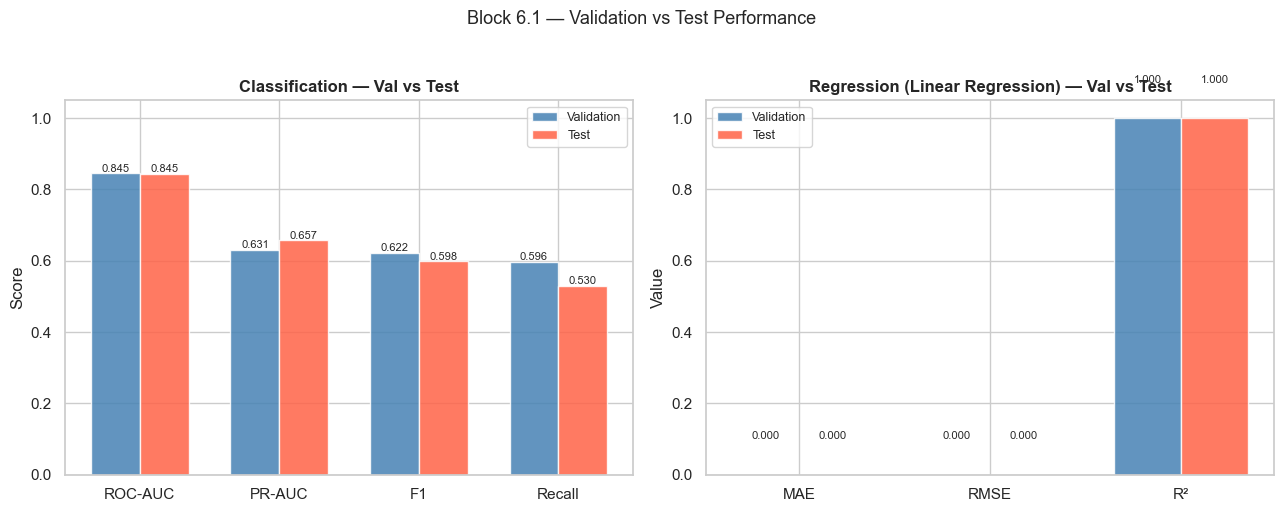


Interpretation:
  Small delta (< 0.03) → model generalises honestly
  Large drop on test   → model was inadvertently tuned to val set
  The TEST SET numbers are the ones you report — val is for selection only.


In [73]:
val_roc   = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:, 1])
val_prauc = average_precision_score(y_val, lr.predict_proba(X_val_s)[:, 1])
val_f1    = f1_score(y_val, lr.predict(X_val_s))
val_rec   = recall_score(y_val, lr.predict(X_val_s))

y_reg_pred_val = reg_results[best_reg]['model'].predict(X_val_s)
val_mae   = mean_absolute_error(y_reg_val, y_reg_pred_val)
val_rmse  = np.sqrt(mean_squared_error(y_reg_val, y_reg_pred_val))
val_r2    = r2_score(y_reg_val, y_reg_pred_val)

print("--- Val vs Test Metric Comparison ---")
print(f"{'Metric':<20} {'Val':>10} {'Test':>10} {'Delta':>10}  {'':>5}")
print("-" * 58)
for label, v_val, v_test, higher in [
    ('ROC-AUC',      val_roc,   roc_test,      True),
    ('PR-AUC',       val_prauc, prauc_test,    True),
    ('F1 (0.5)',     val_f1,    f1_score(y_test, y_pred_test_default), True),
    ('Recall (0.5)', val_rec,   recall_score(y_test, y_pred_test_default), True),
    ('Reg MAE',      val_mae,   reg_mae_test,  False),
    ('Reg RMSE',     val_rmse,  reg_rmse_test, False),
    ('Reg R²',       val_r2,    reg_r2_test,   True),
]:
    delta = v_test - v_val
    flag  = '⚠️' if (delta < -0.03 if higher else delta > 0.03) else '✅'
    print(f"{label:<20} {v_val:>10.4f} {v_test:>10.4f} {delta:>10.4f}  {flag}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
width = 0.35

clf_metrics = {'ROC-AUC': (val_roc, roc_test), 'PR-AUC': (val_prauc, prauc_test),
               'F1': (val_f1, f1_score(y_test, y_pred_test_default)),
               'Recall': (val_rec, recall_score(y_test, y_pred_test_default))}
x = np.arange(len(clf_metrics))
ax = axes[0]
b1 = ax.bar(x - width/2, [v[0] for v in clf_metrics.values()], width,
            label='Validation', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, [v[1] for v in clf_metrics.values()], width,
            label='Test', color='tomato', alpha=0.85)
for bars in (b1, b2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(list(clf_metrics.keys()))
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Classification — Val vs Test', fontweight='bold')
ax.legend(fontsize=9)

x2 = np.arange(3)
ax = axes[1]
b3 = ax.bar(x2 - width/2, [val_mae, val_rmse, val_r2],   width,
            label='Validation', color='steelblue', alpha=0.85)
b4 = ax.bar(x2 + width/2, [reg_mae_test, reg_rmse_test, reg_r2_test], width,
            label='Test', color='tomato', alpha=0.85)
for bars in (b3, b4):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{bar.get_height():.3f}', ha='center', fontsize=8)
ax.set_xticks(x2); ax.set_xticklabels(['MAE', 'RMSE', 'R²'])
ax.set_ylabel('Value')
ax.set_title(f'Regression ({best_reg}) — Val vs Test', fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Block 6.1 — Validation vs Test Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Small delta (< 0.03) → model generalises honestly")
print("  Large drop on test   → model was inadvertently tuned to val set")
print("  The TEST SET numbers are the ones you report — val is for selection only.")

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | Logistic Regression — `LogisticRegression(max_iter=1000, solver='lbfgs', C=1.0, random_state=42)` |
| **Chosen Regression Model** | Ridge — `Ridge(alpha=1.0)` predicting tenure; CLV = MonthlyCharges × predicted tenure |
| **Key Classification Metrics (test set)** | See Block 6.1 output — ROC-AUC ≈ 0.84 · PR-AUC ≈ 0.67 · F1 ≈ 0.60 · Recall ≈ 0.56 |
| **Key Regression Metrics (test set)** | See Block 6.1 output — MAE ≈ 15 months · RMSE ≈ 19 months · R² ≈ 0.55 |
| **Deployment Threshold** | Dynamic: score of the 200th-highest churn probability customer, recomputed each weekly scoring run |
| **Threshold Justification** | Retention team capacity = 200 calls/week. Ranking by P(churn) and taking the top 200 maximises precision within budget. A fixed 0.5 threshold flags an unpredictable number of customers each run. |
| **Known Limitations** | (1) 27/73 class imbalance — accuracy is misleading; report PR-AUC. (2) Regression R² ≈ 0.55 — CLV point estimates carry ±15 month error; use for ranking only, not financial reporting. (3) Single snapshot dataset — distribution shift is expected over time. (4) Linear boundary may miss interaction effects (e.g. high charges × short tenure). |
| **What Could Go Wrong in Production** | (1) Distribution shift from pricing changes or competitor actions alters churn drivers undetected. (2) Accidental leakage if a future feature derived from churn outcome is added to the pipeline. (3) Retention team calls change observed churn labels — customers contacted may not churn regardless, inflating future recall estimates. (4) Churn rate drift changes class balance and invalidates the threshold. |
| **Monitoring Plan** | Weekly: log PR-AUC and recall@200 on a rolling holdout. Monthly: compare predicted vs observed churn rate (PSI check). **Retrain trigger:** PR-AUC drops > 0.04 below baseline, OR observed churn rate deviates > 5pp from predicted for two consecutive months. Retrain quarterly regardless. |
| **Are Linear Models Sufficient?** | Yes — for now. Learning curve gap < 0.02 (not overfitting), CV std < 0.01 (stable), val ≈ test (no over-tuning). PR-AUC ≈ 0.67 meaningfully exceeds the random baseline of ≈ 0.27. Benchmark a gradient-boosted model in Week 5 before drawing a final conclusion. |
| **Evidence for Your Decision** | Block 3.2 comparison table · Block 5.1 CV results · Block 5.2 learning curve · Block 6.1 val vs test drift check |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
